# Different metrics to find the best threshold $\alpha$ for *Regression Pruning*

In [1]:
import os, sys, importlib.util

# 1) Where Jupyter is currently running:
cwd = os.getcwd()
print("Notebook cwd:", cwd)

# 2) Compute the folder above (your project root):
project_root = os.path.abspath(os.path.join(cwd, os.pardir))
print("Project root:", project_root)
print("→ Contains:", os.listdir(project_root))

# 3) Inject it onto sys.path (highest priority):
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print("After hack, sys.path[0]:", sys.path[0])

# 4) Confirm Python can now see lmt_pkg:
print("After hack, spec(lmt_pkg):", importlib.util.find_spec("lmt_pkg"))

from lmt_pkg import lmt_final_implementation as lmt
from lmt_pkg import calibration_functions as calibration
from lmt_pkg import logitboost_j_implementation as logitboost
from lmt_pkg import composite_tree
from lmt_pkg import spline_splitting as spline

Notebook cwd: c:\Users\allis\Desktop\MITACS\LMT-calibration\Alternative tree (linear spline)
Project root: c:\Users\allis\Desktop\MITACS\LMT-calibration
→ Contains: ['.git', 'Alternative pruning', 'Alternative tree (linear spline)', 'Alternative tree (root multi-cuts)', 'Calibration testing', 'Construction and tests', 'desktop.ini', 'Documentation', 'lmt_pkg', 'Papers', 'README.md']
After hack, sys.path[0]: c:\Users\allis\Desktop\MITACS\LMT-calibration
After hack, spec(lmt_pkg): ModuleSpec(name='lmt_pkg', loader=<_frozen_importlib_external.SourceFileLoader object at 0x0000018ED05645B0>, origin='c:\\Users\\allis\\Desktop\\MITACS\\LMT-calibration\\lmt_pkg\\__init__.py', submodule_search_locations=['c:\\Users\\allis\\Desktop\\MITACS\\LMT-calibration\\lmt_pkg'])


In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

# Random seed = 0

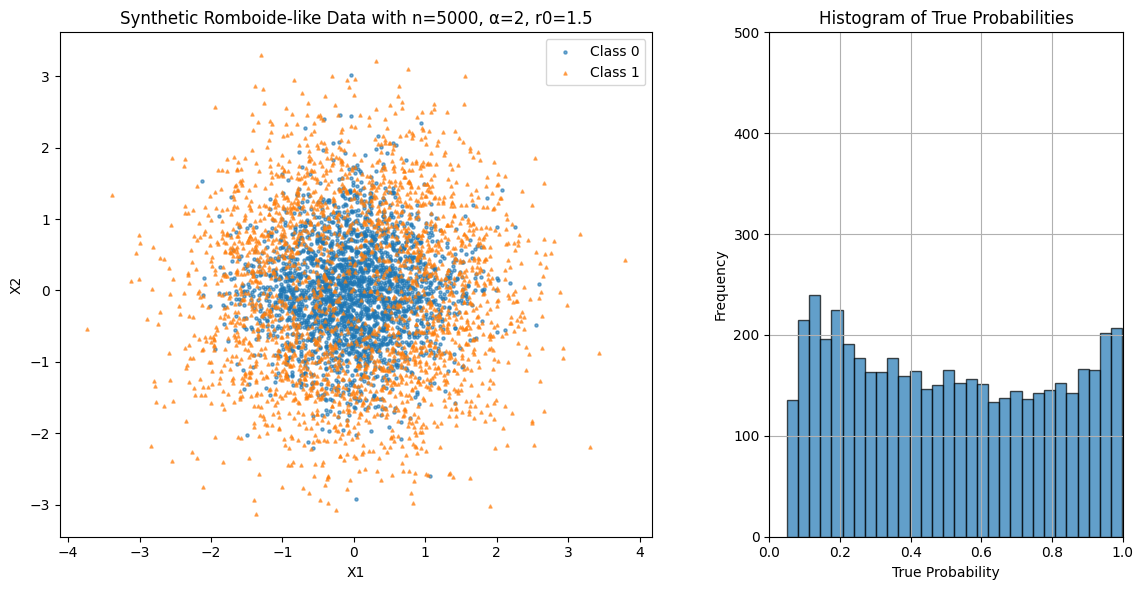

Proportion of positive samples: 0.50


In [116]:
# 1) PARAMETERS
n = 5000
alpha = 2 # controls sharpness of the circle boundary
r0 = 1.5   # target radius
# alpha = 5
# r0 = 1.0   # target radius
# 2) SIMULATE FEATURES from a normal distribution
np.random.seed(0)  # for reproducibility
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
r2 = np.abs(X1) + np.abs(X2)  # r^2 = |X1| + |X2|

# 3) DEFINE TRUE PROBABILITIES USING A SIGMOID ON r^2 - r0
p = 1 / (1 + np.exp(-alpha * (r2 - r0)))

# 4) SAMPLE OUTCOME y ~ Bernoulli(p)
y = np.random.binomial(1, p)


# Subplots for the scatter plot and the histogram
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(1, 2, width_ratios=[2, 1])

# a) SCATTER PLOT
classes = np.unique(y)
ax1 = fig.add_subplot(gs[0])
ax1.set_title(f'Synthetic Romboide-like Data with n={n}, α={alpha}, r0={r0}')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
# Plot the points with different markers for each class
for cls, marker in zip(classes, ['o', '^']):
    ax1.scatter(
        X1[y==cls], 
        X2[y==cls], 
        alpha=0.6, 
        marker=marker, 
        label=f'Class {int(cls)}',
        s=5
    )
ax1.legend()

# b) HISTOGRAM OF PROBABILITIES
ax2 = fig.add_subplot(gs[1])
ax2.set_title('Histogram of True Probabilities')
ax2.set_xlabel('True Probability')
ax2.set_ylabel('Frequency')
ax2.hist(p, bins=30, alpha=0.7, edgecolor='black')
ax2.grid()
# Show the plots in equal proportions without blank spaces
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 500)
ax2.set_aspect('auto', adjustable='box')
ax1.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# Proportion of positive samples
positive_proportion = np.mean(y)
print(f"Proportion of positive samples: {positive_proportion:.2f}")

In [117]:
# import train_test_split
from sklearn.model_selection import train_test_split

# Full X dataset
X = np.column_stack((X1, X2))

# Separate in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  

## Real AUC

In [20]:
from sklearn.metrics import roc_auc_score

# Params
n_large = 1_000_000
alpha = 2
r0 = 1.5

# Monte Carlo simulation for large dataset
X1_large = np.random.normal(0, 1, n_large)
X2_large = np.random.normal(0, 1, n_large)
r2_large = np.abs(X1_large) + np.abs(X2_large)
p_large = 1 / (1 + np.exp(-alpha * (r2_large - r0)))
y_large = np.random.binomial(1, p_large)

# Stimate the AUC for the large dataset
# This is the true AUC, since we know the probabilities
auc_true = roc_auc_score(y_large, p_large)
print(f"True AUC (stimated): {auc_true:.6f}")


True AUC (stimated): 0.831906


## First tree
With the following parameters:
 - `max_depth` = 10
 - `min_samples_leaf` = 20
 - `purity_threshold` = 0.85
 - seed = 0

In [14]:
spline_tree = spline.grow_spline_tree(X_train, y_train, [0,1], max_depth=10, min_samples_leaf=20, purity_threshold=0.85, verbose=True)

Feature 0, tau = -1.29, AUC_L = 0.632, AUC_R = 0.575, Weighted AUC = 0.580
Feature 0, tau = -0.82, AUC_L = 0.664, AUC_R = 0.628, Weighted AUC = 0.636
Feature 0, tau = -0.50, AUC_L = 0.658, AUC_R = 0.677, Weighted AUC = 0.671
Feature 0, tau = -0.25, AUC_L = 0.674, AUC_R = 0.715, Weighted AUC = 0.699
Feature 0, tau = -0.00, AUC_L = 0.707, AUC_R = 0.715, Weighted AUC = 0.711
Feature 0, tau = 0.24, AUC_L = 0.708, AUC_R = 0.697, Weighted AUC = 0.704
Feature 0, tau = 0.51, AUC_L = 0.679, AUC_R = 0.684, Weighted AUC = 0.681
Feature 0, tau = 0.84, AUC_L = 0.632, AUC_R = 0.665, Weighted AUC = 0.639
Feature 0, tau = 1.26, AUC_L = 0.574, AUC_R = 0.646, Weighted AUC = 0.581
Feature 1, tau = -1.27, AUC_L = 0.643, AUC_R = 0.577, Weighted AUC = 0.583
Feature 1, tau = -0.85, AUC_L = 0.666, AUC_R = 0.641, Weighted AUC = 0.646
Feature 1, tau = -0.53, AUC_L = 0.691, AUC_R = 0.683, Weighted AUC = 0.686
Feature 1, tau = -0.26, AUC_L = 0.704, AUC_R = 0.716, Weighted AUC = 0.712
Feature 1, tau = -0.03, AUC_L

In [15]:
tree, node_models = spline.fit_logistic_model_tree_custom(
    X_train, y_train,
    features=[0,1],
    max_depth=10,
    min_samples_leaf=20,
    purity_threshold=0.85,
    verbose=True
)
print("LMT fitted with custom parameters")

pruned_tree0, pruned_node_models0 = spline.regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=0.70, multiclass=False, average='macro', verbose=False)

pruned_tree1, pruned_node_models1 = spline.regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=0.73, multiclass=False, average='macro', verbose=False)

pruned_tree2, pruned_node_models2 = spline.regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=0.75, multiclass=False, average='macro', verbose=False)

Feature 0, tau = -1.29, AUC_L = 0.632, AUC_R = 0.575, Weighted AUC = 0.580
Feature 0, tau = -0.82, AUC_L = 0.664, AUC_R = 0.628, Weighted AUC = 0.636
Feature 0, tau = -0.50, AUC_L = 0.658, AUC_R = 0.677, Weighted AUC = 0.671
Feature 0, tau = -0.25, AUC_L = 0.674, AUC_R = 0.715, Weighted AUC = 0.699
Feature 0, tau = -0.00, AUC_L = 0.707, AUC_R = 0.715, Weighted AUC = 0.711
Feature 0, tau = 0.24, AUC_L = 0.708, AUC_R = 0.697, Weighted AUC = 0.704
Feature 0, tau = 0.51, AUC_L = 0.679, AUC_R = 0.684, Weighted AUC = 0.681
Feature 0, tau = 0.84, AUC_L = 0.632, AUC_R = 0.665, Weighted AUC = 0.639
Feature 0, tau = 1.26, AUC_L = 0.574, AUC_R = 0.646, Weighted AUC = 0.581
Feature 1, tau = -1.27, AUC_L = 0.643, AUC_R = 0.577, Weighted AUC = 0.583
Feature 1, tau = -0.85, AUC_L = 0.666, AUC_R = 0.641, Weighted AUC = 0.646
Feature 1, tau = -0.53, AUC_L = 0.691, AUC_R = 0.683, Weighted AUC = 0.686
Feature 1, tau = -0.26, AUC_L = 0.704, AUC_R = 0.716, Weighted AUC = 0.712
Feature 1, tau = -0.03, AUC_L

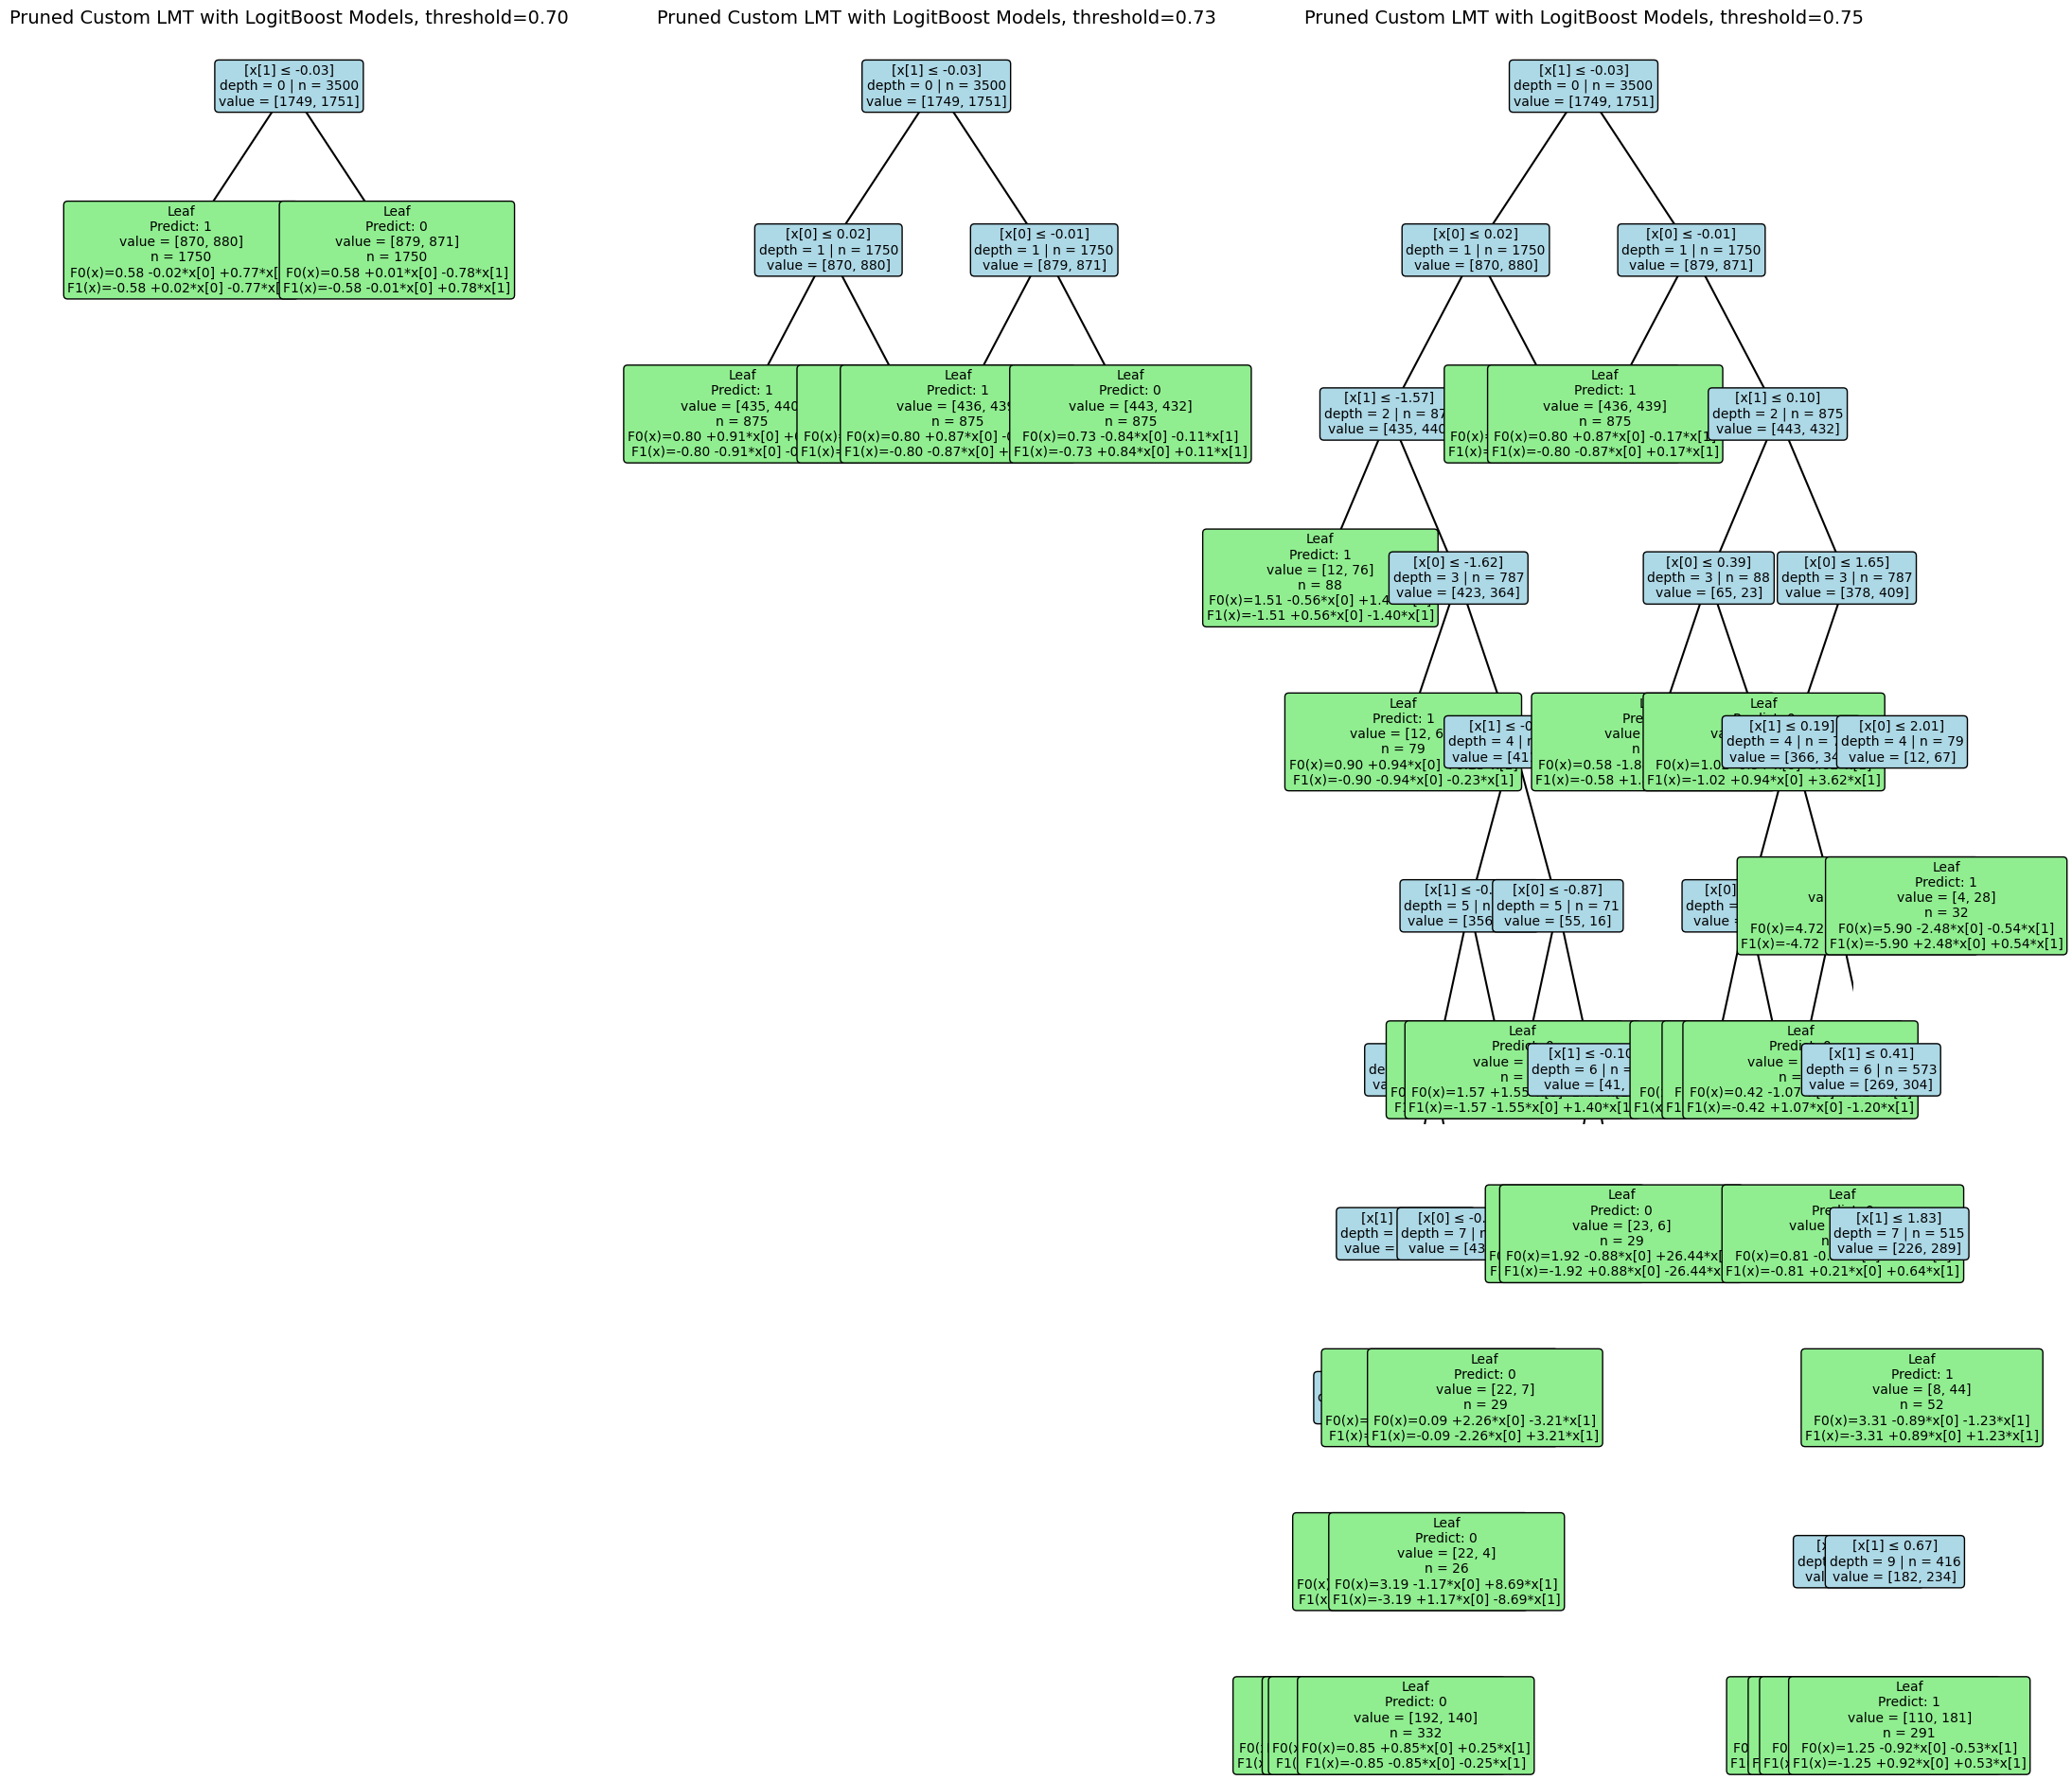

In [16]:
# Trees
fig, ax = plt.subplots(1, 3, figsize=(25, 15))
for axis in ax:
    axis.set_axis_off() 

spline.plot_custom_tree_with_models(pruned_tree0, pruned_node_models0, X_train, ax=ax[0],title="Pruned Custom LMT with LogitBoost Models, threshold=0.70")
spline.plot_custom_tree_with_models(pruned_tree1, pruned_node_models1, X_train, ax=ax[1],title="Pruned Custom LMT with LogitBoost Models, threshold=0.73")
spline.plot_custom_tree_with_models(pruned_tree2, pruned_node_models2, X_train, ax=ax[2],title="Pruned Custom LMT with LogitBoost Models, threshold=0.75")

ax[0].set_title("Pruned Custom LMT with LogitBoost Models, threshold=0.70", fontsize=14)
ax[1].set_title("Pruned Custom LMT with LogitBoost Models, threshold=0.73", fontsize=14)
ax[2].set_title("Pruned Custom LMT with LogitBoost Models, threshold=0.75", fontsize=14)

plt.show()

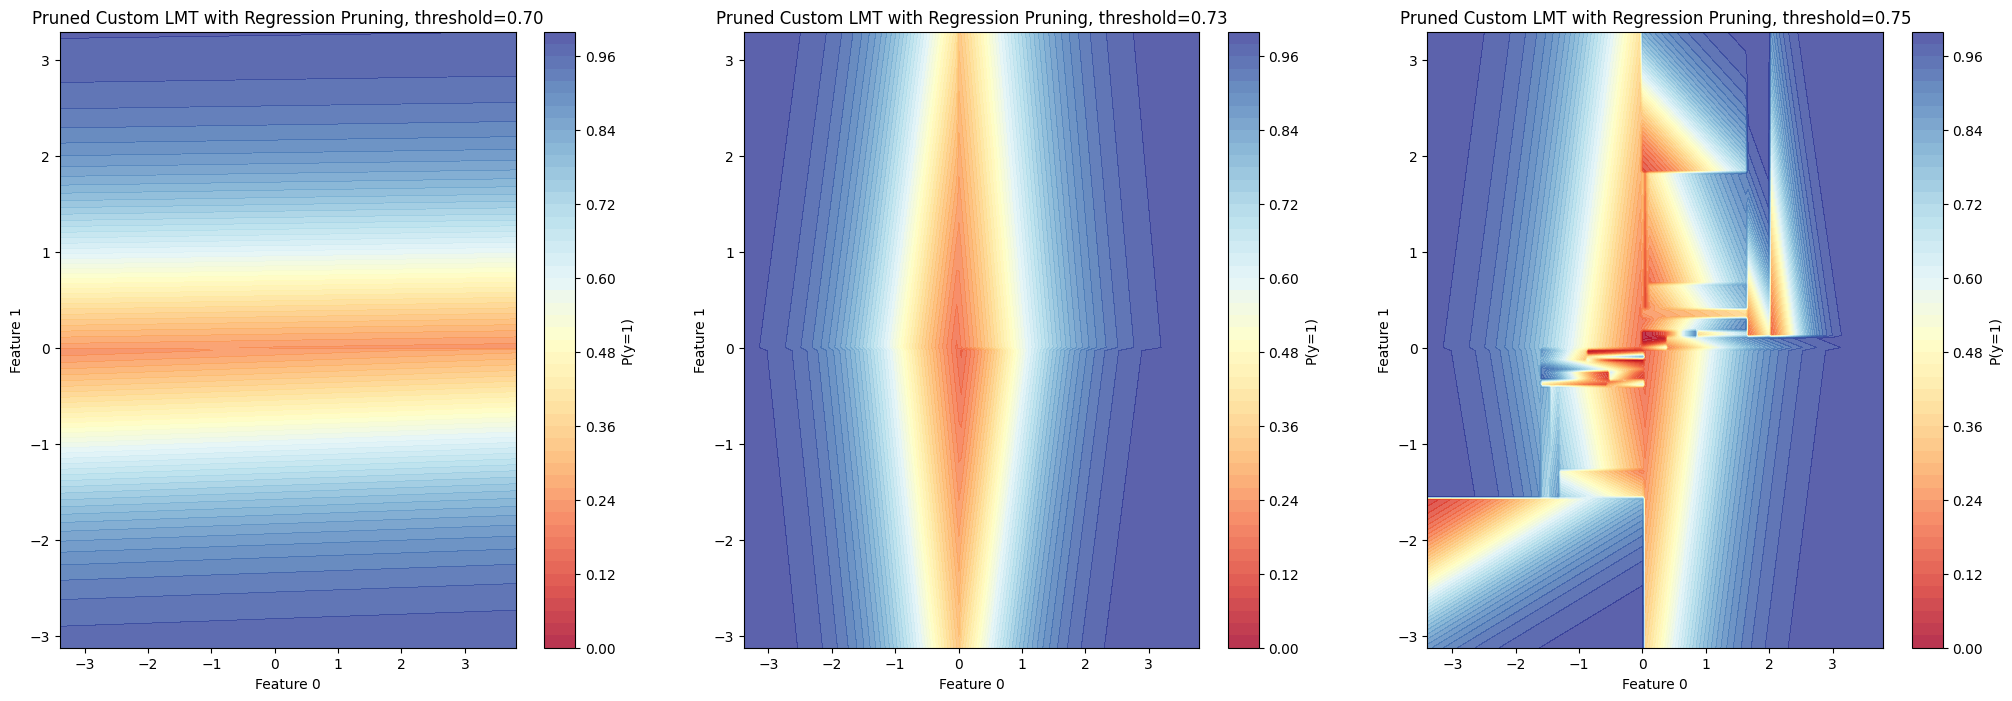

In [17]:
# Proability regions
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

spline.plot_probability_surface_custom_tree(
    pruned_tree0, pruned_node_models0, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title='Pruned Custom LMT with Regression Pruning, threshold=0.70', ax=ax[0]
    )
spline.plot_probability_surface_custom_tree(
    pruned_tree1, pruned_node_models1, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title='Pruned Custom LMT with Regression Pruning, threshold=0.73', ax=ax[1]
    )
spline.plot_probability_surface_custom_tree(
    pruned_tree2, pruned_node_models2, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title='Pruned Custom LMT with Regression Pruning, threshold=0.75', ax=ax[2]
    )

plt.show()

### Metrics

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, log_loss,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from scipy.special import softmax
import math

def compute_ece(y_true, y_prob, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    binids = np.digitize(y_prob, bin_edges) - 1

    ece = 0.0
    for i in range(n_bins):
        bin_mask = binids == i
        bin_size = np.sum(bin_mask)
        if bin_size > 0:
            bin_acc = np.mean(y_true[bin_mask])
            bin_conf = np.mean(y_prob[bin_mask])
            ece += (bin_size / len(y_true)) * abs(bin_acc - bin_conf)
    return ece


# Define thresholds
thresholds = np.concatenate([
    np.arange(0.6, 0.7, 0.05),
    np.arange(0.7, 0.96, 0.01)
])

# Placeholder for results
results = []

# Iterate over thresholds using user's pruning function
for threshold in thresholds:
    pruned_tree, pruned_node_models = spline.regression_pruning_spline_bfs(
        X_train, y_train, tree, node_models,
        threshold=threshold,
        multiclass=False,
        average='macro',
        verbose=False
    )

    # Predict probabilities and labels
    proba = spline.predict_proba_lmt_custom(X_test, pruned_tree, pruned_node_models)
    y_pred = np.argmax(proba, axis=1)

    # Performance metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auc = roc_auc_score(y_test, proba[:, 1])
    ll = log_loss(y_test, proba)
    bs = brier_score_loss(y_test, proba[:, 1])

    # Calibration: ECE
    prob_true, prob_pred = calibration_curve(y_test, proba[:, 1], n_bins=10)
    #ece = np.sum(np.abs(prob_true - prob_pred) * np.histogram(proba[:, 1], bins=10)[0]) / len(y_test)
    ece = compute_ece(y_test, proba[:, 1], n_bins=10)

    # Tree complexity
    def count_nodes(node):
        if node.is_leaf:
            return 1
        return 1 + count_nodes(node.left) + count_nodes(node.right)

    def tree_depth(node):
        if node.is_leaf:
            return 1
        return 1 + max(tree_depth(node.left), tree_depth(node.right))

    depth = tree_depth(pruned_tree)
    complexity = count_nodes(pruned_tree)

    # AIC and BIC: we approximate num params as number of nonzero coefficients + intercepts
    J = proba.shape[1]
    n_params = sum(
        sum(np.any(np.abs(logitboost.extract_linear_models(
            pruned_node_models[nid]['learners'],
            pruned_node_models[nid]['J'],
            X_train.shape[1]
        )[1]) > 1e-6, axis=1))
        for nid in pruned_node_models
    )

    n = len(y_test)
    aic = 2 * n_params + n * math.log(ll)
    bic = math.log(n) * n_params + n * math.log(ll)

    results.append({
        "threshold": threshold,
        "accuracy": acc,
        "f1_score": f1,
        "auc": auc,
        "log_loss": ll,
        "brier_score": bs,
        "ece": ece,
        "depth": depth,
        "complexity": complexity,
        "aic": aic,
        "bic": bic
    })

# Convert to DataFrame
df_results = pd.DataFrame(results)

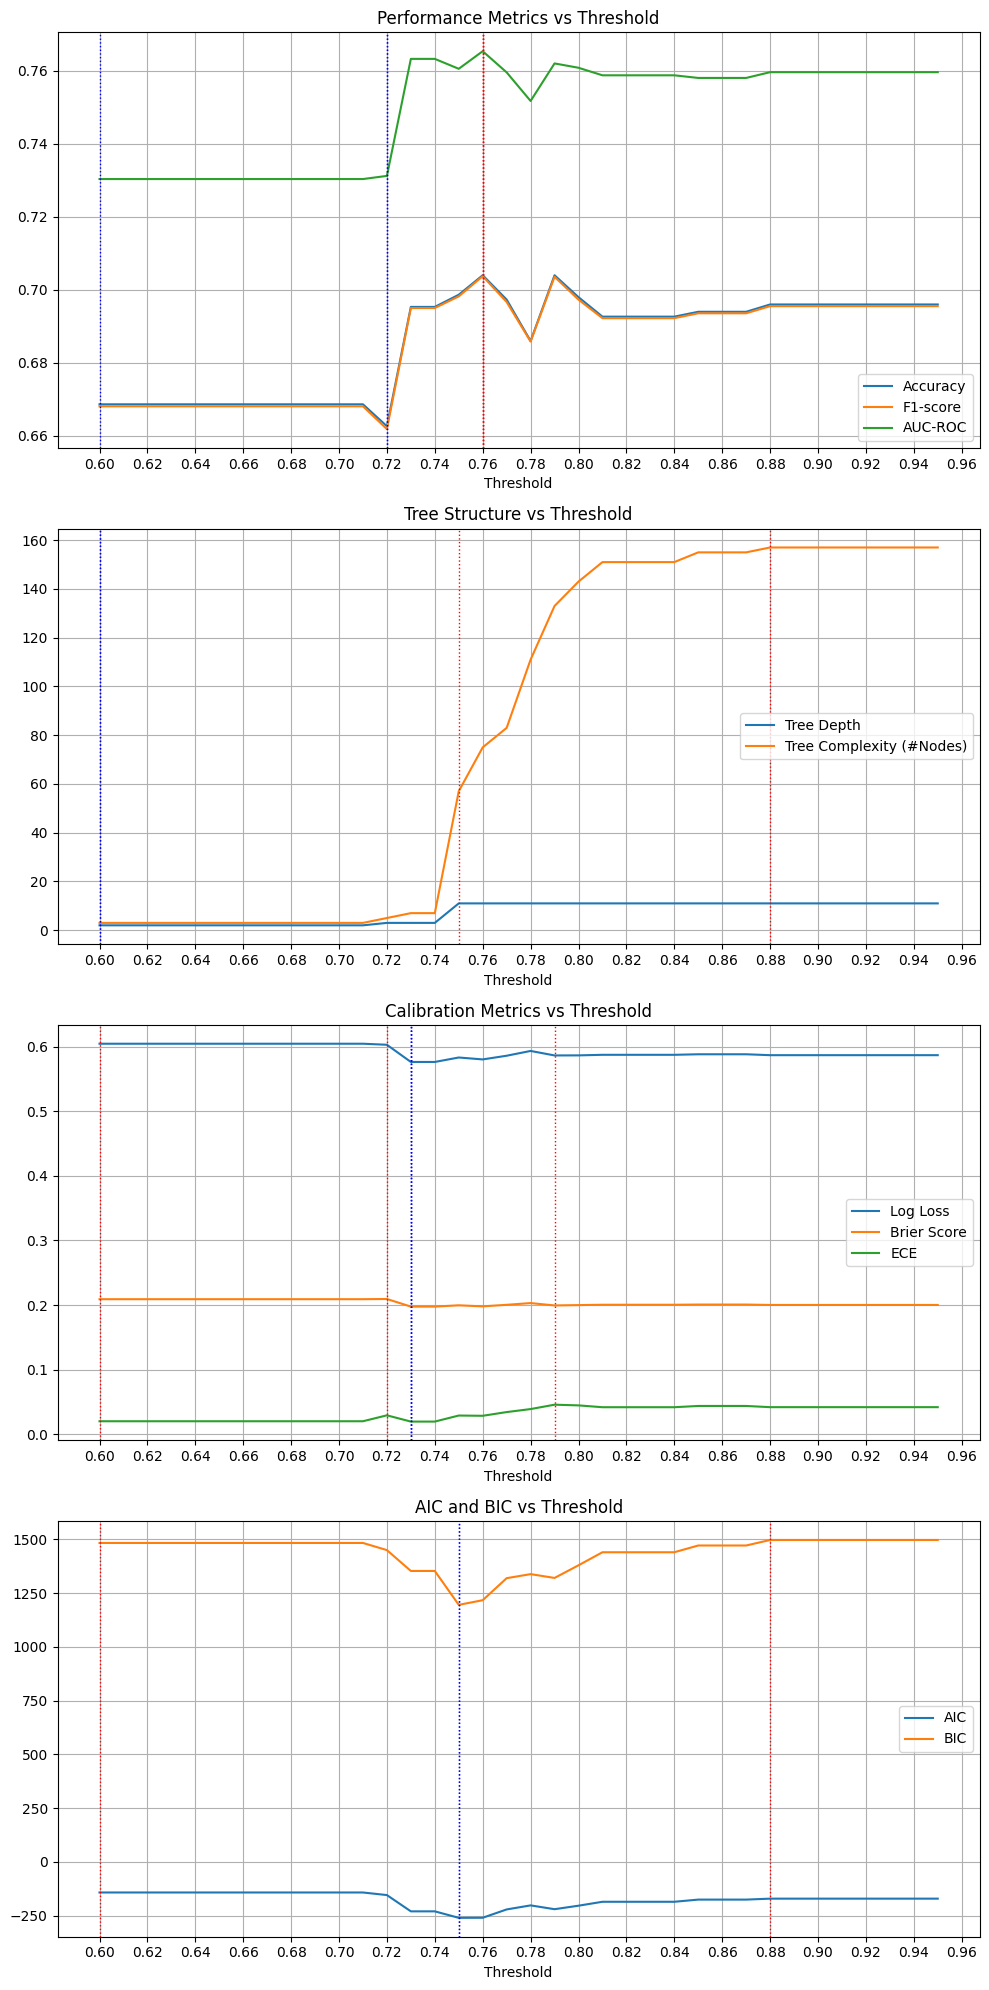

In [37]:
def annotate_min_max(ax, x, y, label):
    min_idx = y.idxmin()
    max_idx = y.idxmax()
    ax.axvline(x[min_idx], color='blue', linestyle='dotted', linewidth=1)
    ax.axvline(x[max_idx], color='red', linestyle='dotted', linewidth=1)
    return x[min_idx], y[min_idx], x[max_idx], y[max_idx]


# Plotting
fig, axs = plt.subplots(4, 1, figsize=(10, 20))
from matplotlib.ticker import MaxNLocator

for ax in axs:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=25))

# 1. Performance Metrics
axs[0].plot(df_results["threshold"], df_results["accuracy"], label="Accuracy")
axs[0].plot(df_results["threshold"], df_results["f1_score"], label="F1-score")
axs[0].plot(df_results["threshold"], df_results["auc"], label="AUC-ROC")
axs[0].set_title("Performance Metrics vs Threshold")
axs[0].set_xlabel("Threshold")
axs[0].legend()
axs[0].grid()
for metric in ["accuracy", "f1_score", "auc"]:
    annotate_min_max(axs[0], df_results["threshold"], df_results[metric], metric)

# 2. Tree Structure Metrics
axs[1].plot(df_results["threshold"], df_results["depth"], label="Tree Depth")
axs[1].plot(df_results["threshold"], df_results["complexity"], label="Tree Complexity (#Nodes)")
axs[1].set_title("Tree Structure vs Threshold")
axs[1].set_xlabel("Threshold")
axs[1].legend()
axs[1].grid()
for metric in ["depth", "complexity"]:
    annotate_min_max(axs[1], df_results["threshold"], df_results[metric], metric)

# 3. Calibration Metrics
axs[2].plot(df_results["threshold"], df_results["log_loss"], label="Log Loss")
axs[2].plot(df_results["threshold"], df_results["brier_score"], label="Brier Score")
axs[2].plot(df_results["threshold"], df_results["ece"], label="ECE")
axs[2].set_title("Calibration Metrics vs Threshold")
axs[2].set_xlabel("Threshold")
axs[2].legend()
axs[2].grid()
for metric in ["log_loss", "brier_score", "ece"]:
    annotate_min_max(axs[2], df_results["threshold"], df_results[metric], metric)

# 4. AIC/BIC in separate plot
axs[3].plot(df_results["threshold"], df_results["aic"], label="AIC")
axs[3].plot(df_results["threshold"], df_results["bic"], label="BIC")
axs[3].set_title("AIC and BIC vs Threshold")
axs[3].set_xlabel("Threshold")
axs[3].legend()
axs[3].grid()
for metric in ["aic", "bic"]:
    annotate_min_max(axs[3], df_results["threshold"], df_results[metric], metric)

plt.tight_layout()
plt.show()

In [28]:
summary_rows = []

for metric in ["accuracy", "f1_score", "auc", "log_loss", "brier_score", "ece", "depth", "complexity", "aic", "bic"]:
    min_val = df_results[metric].min()
    max_val = df_results[metric].max()
    mean_val = df_results[metric].mean()
    threshold_min = df_results.loc[df_results[metric].idxmin(), "threshold"]
    threshold_max = df_results.loc[df_results[metric].idxmax(), "threshold"]

    summary_rows.append({
        "metric": metric,
        "mean_value": mean_val,
        "min_value": min_val,
        "min_threshold": threshold_min,
        "max_value": max_val,
        "max_threshold": threshold_max
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,metric,mean_value,min_value,min_threshold,max_value,max_threshold
0,accuracy,0.690595,0.662667,0.72,0.704000,0.76
1,f1_score,0.690141,0.661888,0.72,0.703745,0.76
2,auc,0.754453,0.730336,0.60,0.765330,0.76
3,log_loss,0.589461,0.576550,0.73,0.604794,0.60
4,brier_score,0.201658,0.197598,0.73,0.209372,0.72
5,ece,0.035765,0.019492,0.73,0.045659,0.79
6,depth,8.857143,2.000000,0.60,11.000000,0.75
7,complexity,105.642857,3.000000,0.60,157.000000,0.88
8,aic,-185.234655,-260.176799,0.75,-142.300187,0.60
9,bic,1429.225311,1195.645587,0.75,1497.403952,0.88


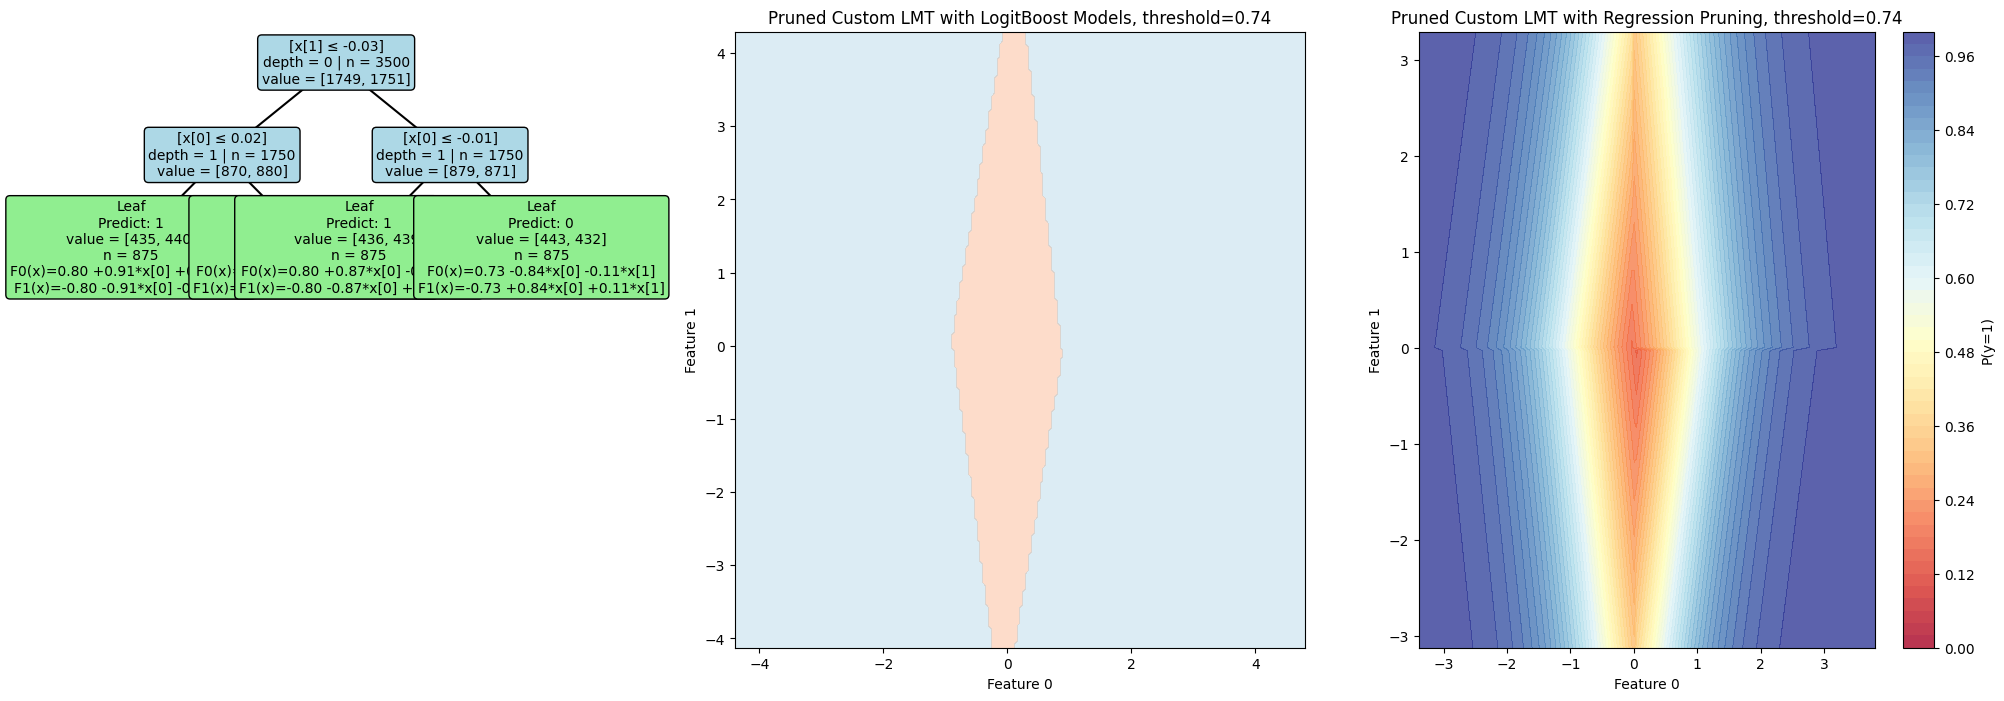

In [40]:
threshold_test = 0.74  # Example threshold for testing

pruned_tree_test, pruned_node_models_test = spline.regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=threshold_test, multiclass=False, average='macro', verbose=False)

# Proability regions
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

spline.plot_custom_tree_with_models(pruned_tree_test, pruned_node_models_test, X_train, ax=ax[0],title=f"Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}")
ax[0].set_axis_off() 

spline.plot_decision_regions_custom_tree(X_train, y_train, pruned_tree_test, pruned_node_models_test,
    feature_pair=(0, 1), show_scatter=False, title=f'Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}', ax=ax[1])

spline.plot_probability_surface_custom_tree(
    pruned_tree_test, pruned_node_models_test, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title=f'Pruned Custom LMT with Regression Pruning, threshold={threshold_test}', ax=ax[2]
    )

plt.show()

## Second tree
Training iteration 7/30 with parameters: {'max_depth': 12, 'min_samples_leaf': 10, 'pruning_threshold': 0.75, 'purity_threshold': 0.75}
Training time: 17.40 seconds
Accuracy: 0.6953

Training iteration 10/30 with parameters: {'max_depth': 6, 'min_samples_leaf': 20, 'pruning_threshold': 0.85, 'purity_threshold': 0.8}
Training time: 10.03 seconds
Accuracy: 0.6953

Training iteration 24/30 with parameters: {'max_depth': 6, 'min_samples_leaf': 20, 'pruning_threshold': 0.8, 'purity_threshold': 0.8}
Training time: 9.97 seconds
Accuracy: 0.6953

In [47]:
def results_from_tree(max_depth=10, min_samples_leaf=20, purity_threshold=0.85):
    tree, node_models = spline.fit_logistic_model_tree_custom(
    X_train, y_train,
    features=[0,1],
    max_depth=max_depth,
    min_samples_leaf=min_samples_leaf,
    purity_threshold=purity_threshold,
    verbose=True
    )

    # Define thresholds
    thresholds = np.concatenate([
        np.arange(0.6, 0.7, 0.05),
        np.arange(0.7, 0.96, 0.01)
    ])

    # Placeholder for results
    results = []

    # Iterate over thresholds using user's pruning function
    for threshold in thresholds:
        pruned_tree, pruned_node_models = spline.regression_pruning_spline_bfs(
            X_train, y_train, tree, node_models,
            threshold=threshold,
            multiclass=False,
            average='macro',
            verbose=False
        )

        # Predict probabilities and labels
        proba = spline.predict_proba_lmt_custom(X_test, pruned_tree, pruned_node_models)
        y_pred = np.argmax(proba, axis=1)

        # Performance metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro')
        auc = roc_auc_score(y_test, proba[:, 1])
        ll = log_loss(y_test, proba)
        bs = brier_score_loss(y_test, proba[:, 1])

        # Calibration: ECE
        prob_true, prob_pred = calibration_curve(y_test, proba[:, 1], n_bins=10)
        #ece = np.sum(np.abs(prob_true - prob_pred) * np.histogram(proba[:, 1], bins=10)[0]) / len(y_test)
        ece = compute_ece(y_test, proba[:, 1], n_bins=10)

        # Tree complexity
        def count_nodes(node):
            if node.is_leaf:
                return 1
            return 1 + count_nodes(node.left) + count_nodes(node.right)

        def tree_depth(node):
            if node.is_leaf:
                return 1
            return 1 + max(tree_depth(node.left), tree_depth(node.right))

        depth = tree_depth(pruned_tree)
        complexity = count_nodes(pruned_tree)

        # AIC and BIC: we approximate num params as number of nonzero coefficients + intercepts
        J = proba.shape[1]
        n_params = sum(
            sum(np.any(np.abs(logitboost.extract_linear_models(
                pruned_node_models[nid]['learners'],
                pruned_node_models[nid]['J'],
                X_train.shape[1]
            )[1]) > 1e-6, axis=1))
            for nid in pruned_node_models
        )

        n = len(y_test)
        aic = 2 * n_params + n * math.log(ll)
        bic = math.log(n) * n_params + n * math.log(ll)

        results.append({
            "threshold": threshold,
            "accuracy": acc,
            "f1_score": f1,
            "auc": auc,
            "log_loss": ll,
            "brier_score": bs,
            "ece": ece,
            "depth": depth,
            "complexity": complexity,
            "aic": aic,
            "bic": bic
        })

    # Convert to DataFrame
    df_results = pd.DataFrame(results)


    # Summary df
    summary_rows = []

    for metric in ["accuracy", "f1_score", "auc", "log_loss", "brier_score", "ece", "depth", "complexity", "aic", "bic"]:
        min_val = df_results[metric].min()
        max_val = df_results[metric].max()
        mean_val = df_results[metric].mean()
        threshold_min = df_results.loc[df_results[metric].idxmin(), "threshold"]
        threshold_max = df_results.loc[df_results[metric].idxmax(), "threshold"]

        summary_rows.append({
            "metric": metric,
            "mean_value": mean_val,
            "min_value": min_val,
            "min_threshold": threshold_min,
            "max_value": max_val,
            "max_threshold": threshold_max
        })

    df_summary = pd.DataFrame(summary_rows)

    return df_results, df_summary, tree, node_models

In [48]:
results, summary, tree, node_models = results_from_tree(max_depth=12, min_samples_leaf=10, purity_threshold=0.75)

Feature 0, tau = -1.29, AUC_L = 0.632, AUC_R = 0.575, Weighted AUC = 0.580
Feature 0, tau = -0.82, AUC_L = 0.664, AUC_R = 0.628, Weighted AUC = 0.636
Feature 0, tau = -0.50, AUC_L = 0.658, AUC_R = 0.677, Weighted AUC = 0.671
Feature 0, tau = -0.25, AUC_L = 0.674, AUC_R = 0.715, Weighted AUC = 0.699
Feature 0, tau = -0.00, AUC_L = 0.707, AUC_R = 0.715, Weighted AUC = 0.711
Feature 0, tau = 0.24, AUC_L = 0.708, AUC_R = 0.697, Weighted AUC = 0.704
Feature 0, tau = 0.51, AUC_L = 0.679, AUC_R = 0.684, Weighted AUC = 0.681
Feature 0, tau = 0.84, AUC_L = 0.632, AUC_R = 0.665, Weighted AUC = 0.639
Feature 0, tau = 1.26, AUC_L = 0.574, AUC_R = 0.646, Weighted AUC = 0.581
Feature 1, tau = -1.27, AUC_L = 0.643, AUC_R = 0.577, Weighted AUC = 0.583
Feature 1, tau = -0.85, AUC_L = 0.666, AUC_R = 0.641, Weighted AUC = 0.646
Feature 1, tau = -0.53, AUC_L = 0.691, AUC_R = 0.683, Weighted AUC = 0.686
Feature 1, tau = -0.26, AUC_L = 0.704, AUC_R = 0.716, Weighted AUC = 0.712
Feature 1, tau = -0.03, AUC_L

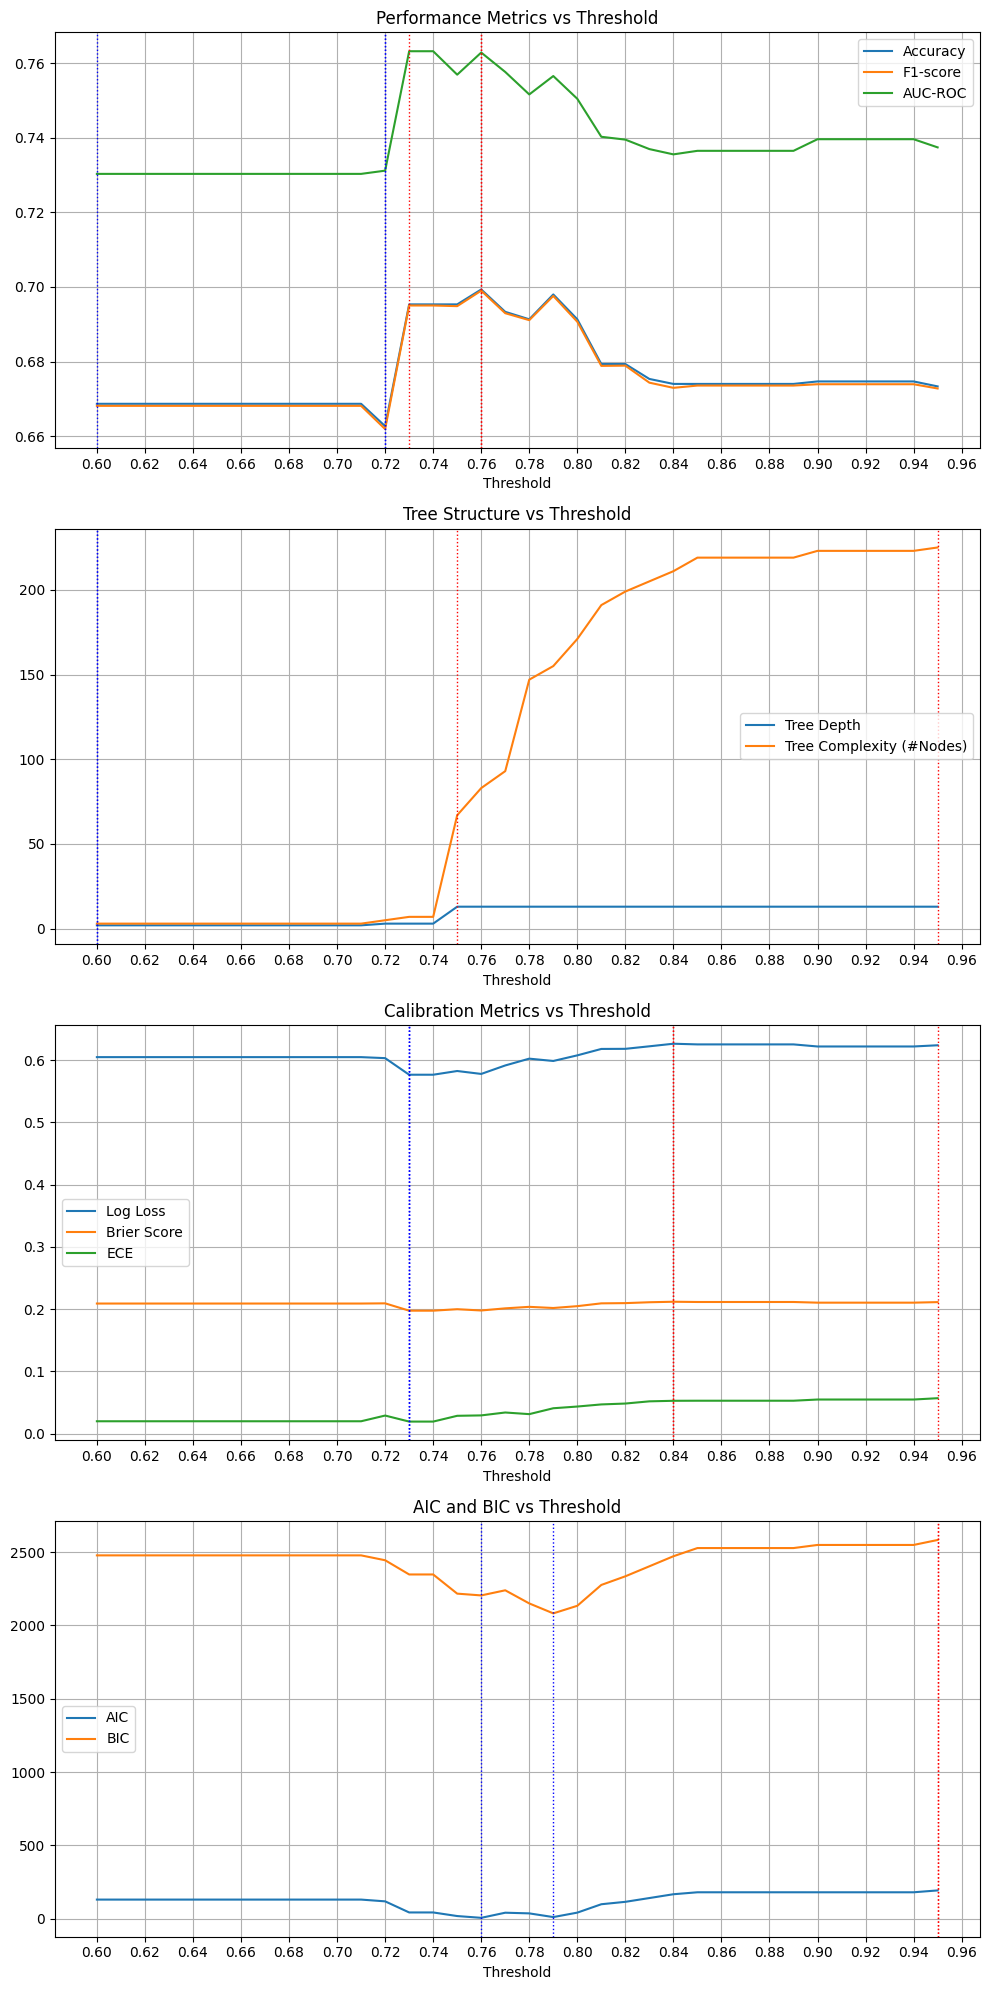

In [ ]:
# Plotting
fig, axs = plt.subplots(4, 1, figsize=(10, 20))
from matplotlib.ticker import MaxNLocator

for ax in axs:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=25))

df_results = results

# 1. Performance Metrics
axs[0].plot(df_results["threshold"], df_results["accuracy"], label="Accuracy")
axs[0].plot(df_results["threshold"], df_results["f1_score"], label="F1-score")
axs[0].plot(df_results["threshold"], df_results["auc"], label="AUC-ROC")
axs[0].set_title("Performance Metrics vs Threshold")
axs[0].set_xlabel("Threshold")
axs[0].legend()
axs[0].grid()
for metric in ["accuracy", "f1_score", "auc"]:
    annotate_min_max(axs[0], df_results["threshold"], df_results[metric], metric)

# 2. Tree Structure Metrics
axs[1].plot(df_results["threshold"], df_results["depth"], label="Tree Depth")
axs[1].plot(df_results["threshold"], df_results["complexity"], label="Tree Complexity (#Nodes)")
axs[1].set_title("Tree Structure vs Threshold")
axs[1].set_xlabel("Threshold")
axs[1].legend()
axs[1].grid()
for metric in ["depth", "complexity"]:
    annotate_min_max(axs[1], df_results["threshold"], df_results[metric], metric)

# 3. Calibration Metrics
axs[2].plot(df_results["threshold"], df_results["log_loss"], label="Log Loss")
axs[2].plot(df_results["threshold"], df_results["brier_score"], label="Brier Score")
axs[2].plot(df_results["threshold"], df_results["ece"], label="ECE")
axs[2].set_title("Calibration Metrics vs Threshold")
axs[2].set_xlabel("Threshold")
axs[2].legend()
axs[2].grid()
for metric in ["log_loss", "brier_score", "ece"]:
    annotate_min_max(axs[2], df_results["threshold"], df_results[metric], metric)

# 4. AIC/BIC in separate plot
axs[3].plot(df_results["threshold"], df_results["aic"], label="AIC")
axs[3].plot(df_results["threshold"], df_results["bic"], label="BIC")
axs[3].set_title("AIC and BIC vs Threshold")
axs[3].set_xlabel("Threshold")
axs[3].legend()
axs[3].grid()
for metric in ["aic", "bic"]:
    annotate_min_max(axs[3], df_results["threshold"], df_results[metric], metric)

plt.tight_layout()
plt.show()

In [50]:
summary

,metric,mean_value,min_value,min_threshold,max_value,max_threshold
0,accuracy,0.679333,0.662667,0.72,0.699333,0.76
1,f1_score,0.678779,0.661888,0.72,0.699012,0.76
2,auc,0.742350,0.730336,0.60,0.763235,0.73
3,log_loss,0.610002,0.576550,0.73,0.626329,0.84
4,brier_score,0.207652,0.197598,0.73,0.211950,0.84
5,ece,0.041190,0.019492,0.73,0.057029,0.95
6,depth,10.357143,2.000000,0.60,13.000000,0.75
7,complexity,142.428571,3.000000,0.60,225.000000,0.95
8,aic,120.596521,5.252262,0.76,192.247950,0.95
9,bic,2412.112570,2082.487835,0.79,2583.197124,0.95


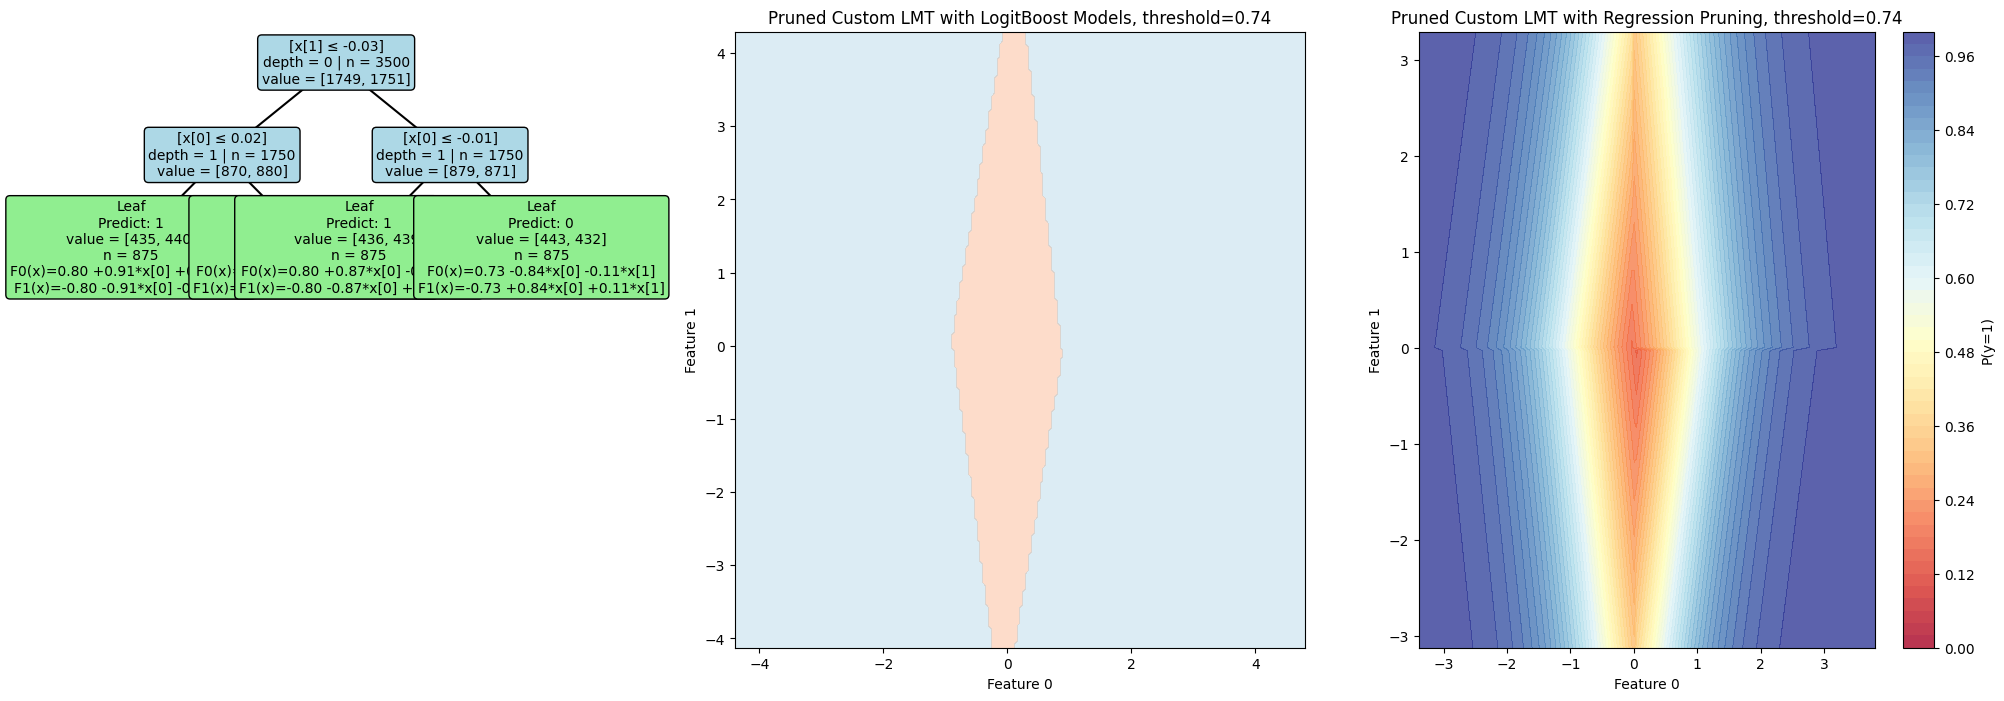

In [51]:
threshold_test = 0.74  # Example threshold for testing

pruned_tree_test, pruned_node_models_test = spline.regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=threshold_test, multiclass=False, average='macro', verbose=False)

# Proability regions
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

spline.plot_custom_tree_with_models(pruned_tree_test, pruned_node_models_test, X_train, ax=ax[0],title=f"Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}")
ax[0].set_axis_off() 

spline.plot_decision_regions_custom_tree(X_train, y_train, pruned_tree_test, pruned_node_models_test,
    feature_pair=(0, 1), show_scatter=False, title=f'Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}', ax=ax[1])

spline.plot_probability_surface_custom_tree(
    pruned_tree_test, pruned_node_models_test, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title=f'Pruned Custom LMT with Regression Pruning, threshold={threshold_test}', ax=ax[2]
    )

plt.show()

## Third tree

In [118]:
results, summary, tree, node_models = results_from_tree(max_depth=6, min_samples_leaf=20, purity_threshold=0.8)

Feature 0, tau = -1.29, AUC_L = 0.632, AUC_R = 0.575, Weighted AUC = 0.580
Feature 0, tau = -0.82, AUC_L = 0.664, AUC_R = 0.628, Weighted AUC = 0.636
Feature 0, tau = -0.50, AUC_L = 0.658, AUC_R = 0.677, Weighted AUC = 0.671
Feature 0, tau = -0.25, AUC_L = 0.674, AUC_R = 0.715, Weighted AUC = 0.699
Feature 0, tau = -0.00, AUC_L = 0.707, AUC_R = 0.715, Weighted AUC = 0.711
Feature 0, tau = 0.24, AUC_L = 0.708, AUC_R = 0.697, Weighted AUC = 0.704
Feature 0, tau = 0.51, AUC_L = 0.679, AUC_R = 0.684, Weighted AUC = 0.681
Feature 0, tau = 0.84, AUC_L = 0.632, AUC_R = 0.665, Weighted AUC = 0.639
Feature 0, tau = 1.26, AUC_L = 0.574, AUC_R = 0.646, Weighted AUC = 0.581
Feature 1, tau = -1.27, AUC_L = 0.643, AUC_R = 0.577, Weighted AUC = 0.583
Feature 1, tau = -0.85, AUC_L = 0.666, AUC_R = 0.641, Weighted AUC = 0.646
Feature 1, tau = -0.53, AUC_L = 0.691, AUC_R = 0.683, Weighted AUC = 0.686
Feature 1, tau = -0.26, AUC_L = 0.704, AUC_R = 0.716, Weighted AUC = 0.712
Feature 1, tau = -0.03, AUC_L

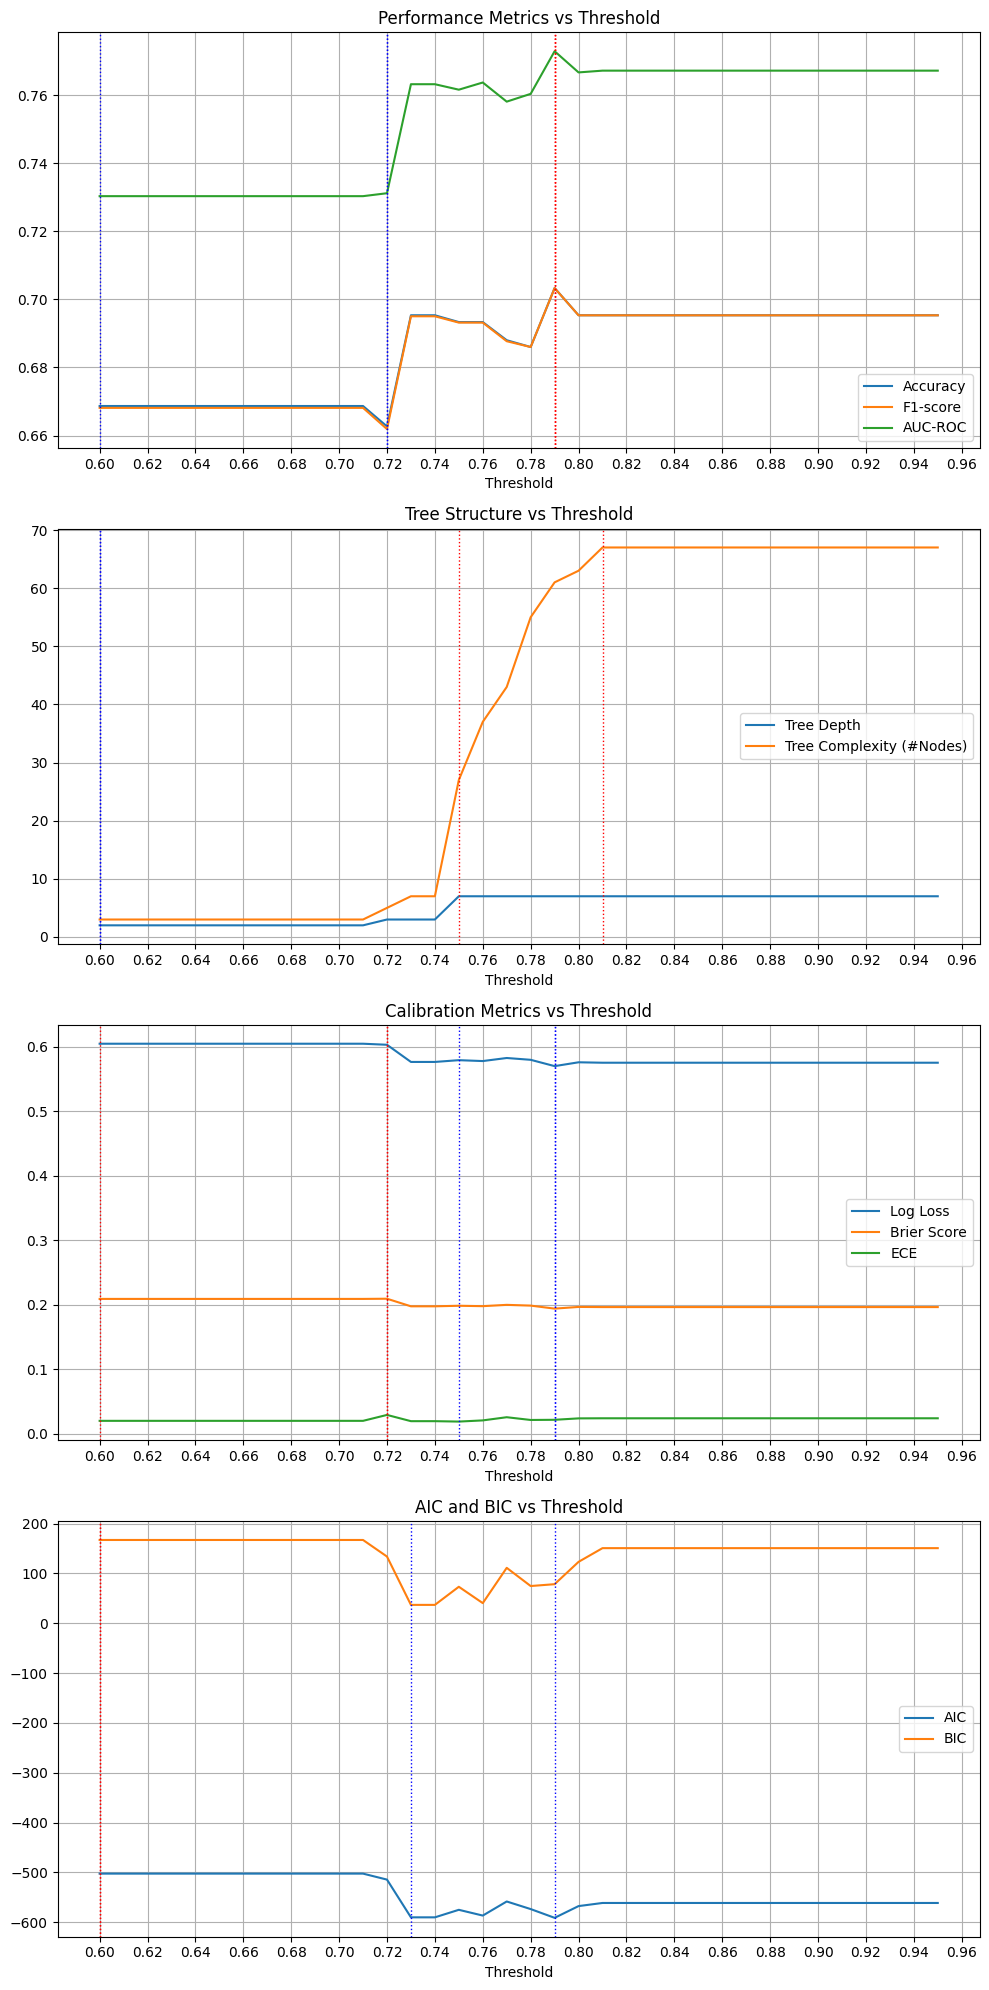

In [119]:
# Plotting
fig, axs = plt.subplots(4, 1, figsize=(10, 20))
from matplotlib.ticker import MaxNLocator

for ax in axs:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=25))

df_results = results

# 1. Performance Metrics
axs[0].plot(df_results["threshold"], df_results["accuracy"], label="Accuracy")
axs[0].plot(df_results["threshold"], df_results["f1_score"], label="F1-score")
axs[0].plot(df_results["threshold"], df_results["auc"], label="AUC-ROC")
axs[0].set_title("Performance Metrics vs Threshold")
axs[0].set_xlabel("Threshold")
axs[0].legend()
axs[0].grid()
for metric in ["accuracy", "f1_score", "auc"]:
    annotate_min_max(axs[0], df_results["threshold"], df_results[metric], metric)

# 2. Tree Structure Metrics
axs[1].plot(df_results["threshold"], df_results["depth"], label="Tree Depth")
axs[1].plot(df_results["threshold"], df_results["complexity"], label="Tree Complexity (#Nodes)")
axs[1].set_title("Tree Structure vs Threshold")
axs[1].set_xlabel("Threshold")
axs[1].legend()
axs[1].grid()
for metric in ["depth", "complexity"]:
    annotate_min_max(axs[1], df_results["threshold"], df_results[metric], metric)

# 3. Calibration Metrics
axs[2].plot(df_results["threshold"], df_results["log_loss"], label="Log Loss")
axs[2].plot(df_results["threshold"], df_results["brier_score"], label="Brier Score")
axs[2].plot(df_results["threshold"], df_results["ece"], label="ECE")
axs[2].set_title("Calibration Metrics vs Threshold")
axs[2].set_xlabel("Threshold")
axs[2].legend()
axs[2].grid()
for metric in ["log_loss", "brier_score", "ece"]:
    annotate_min_max(axs[2], df_results["threshold"], df_results[metric], metric)

# 4. AIC/BIC in separate plot
axs[3].plot(df_results["threshold"], df_results["aic"], label="AIC")
axs[3].plot(df_results["threshold"], df_results["bic"], label="BIC")
axs[3].set_title("AIC and BIC vs Threshold")
axs[3].set_xlabel("Threshold")
axs[3].legend()
axs[3].grid()
for metric in ["aic", "bic"]:
    annotate_min_max(axs[3], df_results["threshold"], df_results[metric], metric)

plt.tight_layout()
plt.show()

In [120]:
summary

,metric,mean_value,min_value,min_threshold,max_value,max_threshold
0,accuracy,0.689905,0.662667,0.72,0.703333,0.79
1,f1_score,0.689746,0.661888,0.72,0.703317,0.79
2,auc,0.759673,0.730336,0.60,0.772929,0.79
3,log_loss,0.581118,0.570061,0.79,0.604794,0.60
4,brier_score,0.199019,0.194020,0.79,0.209372,0.72
5,ece,0.022848,0.018856,0.75,0.029176,0.72
6,depth,5.857143,2.000000,0.60,7.000000,0.75
7,complexity,47.214286,3.000000,0.60,67.000000,0.81
8,aic,-556.185179,-591.019090,0.79,-502.300187,0.60
9,bic,129.979282,36.920250,0.73,167.165582,0.60


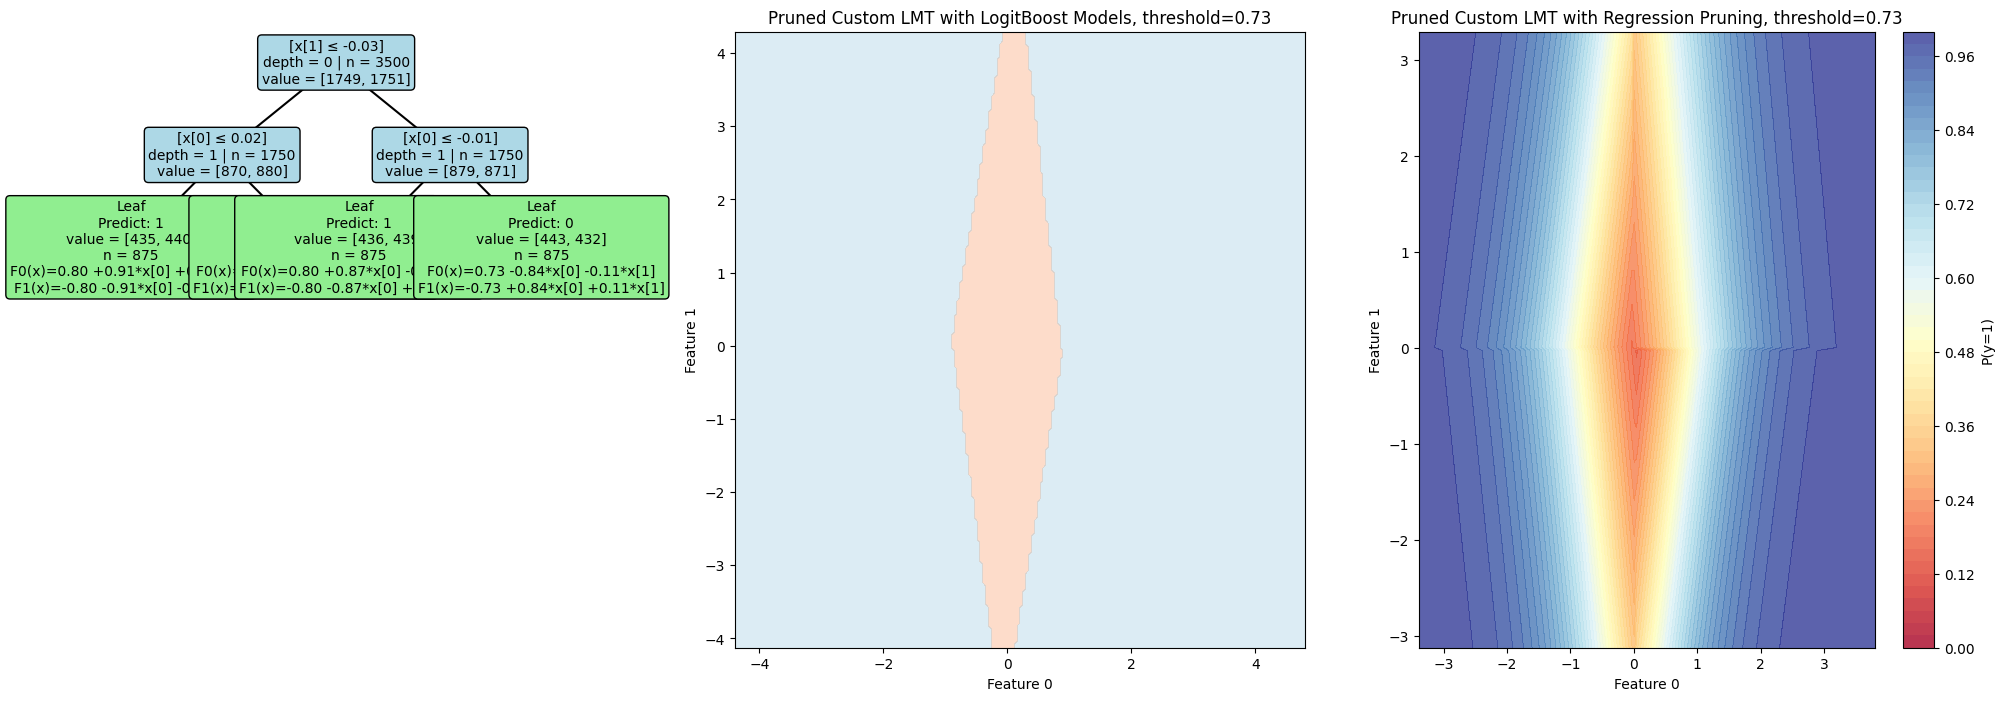

In [124]:
threshold_test = 0.73  # Example threshold for testing

pruned_tree_test, pruned_node_models_test = spline.regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=threshold_test, multiclass=False, average='macro', verbose=False)

# Proability regions
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

spline.plot_custom_tree_with_models(pruned_tree_test, pruned_node_models_test, X_train, ax=ax[0],title=f"Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}")
ax[0].set_axis_off() 

spline.plot_decision_regions_custom_tree(X_train, y_train, pruned_tree_test, pruned_node_models_test,
    feature_pair=(0, 1), show_scatter=False, title=f'Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}', ax=ax[1])

spline.plot_probability_surface_custom_tree(
    pruned_tree_test, pruned_node_models_test, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title=f'Pruned Custom LMT with Regression Pruning, threshold={threshold_test}', ax=ax[2]
    )

plt.show()

# Random seed = 10

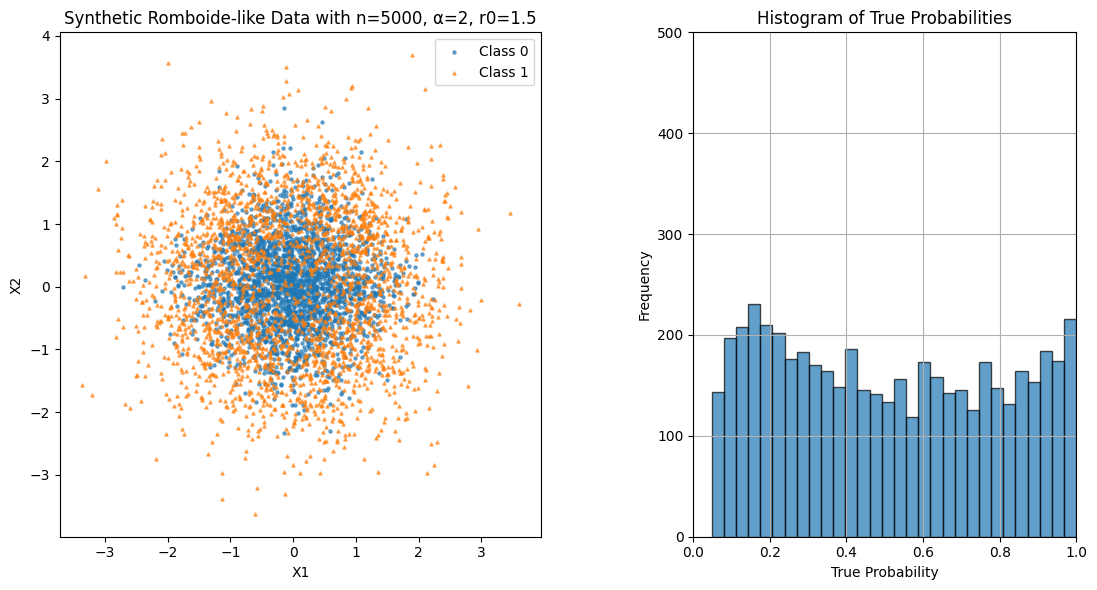

Proportion of positive samples: 0.51


In [203]:
# 1) PARAMETERS
n = 5_000
alpha = 2 # controls sharpness of the circle boundary
r0 = 1.5   # target radius
# alpha = 5
# r0 = 1.0   # target radius
# 2) SIMULATE FEATURES from a normal distribution
np.random.seed(10)  # for reproducibility
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
r2 = np.abs(X1) + np.abs(X2)  # r^2 = |X1| + |X2|

# 3) DEFINE TRUE PROBABILITIES USING A SIGMOID ON r^2 - r0
p = 1 / (1 + np.exp(-alpha * (r2 - r0)))

# 4) SAMPLE OUTCOME y ~ Bernoulli(p)
y = np.random.binomial(1, p)


# Subplots for the scatter plot and the histogram
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(1, 2, width_ratios=[2, 1])

# a) SCATTER PLOT
classes = np.unique(y)
ax1 = fig.add_subplot(gs[0])
ax1.set_title(f'Synthetic Romboide-like Data with n={n}, α={alpha}, r0={r0}')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
# Plot the points with different markers for each class
for cls, marker in zip(classes, ['o', '^']):
    ax1.scatter(
        X1[y==cls], 
        X2[y==cls], 
        alpha=0.6, 
        marker=marker, 
        label=f'Class {int(cls)}',
        s=5
    )
ax1.legend()

# b) HISTOGRAM OF PROBABILITIES
ax2 = fig.add_subplot(gs[1])
ax2.set_title('Histogram of True Probabilities')
ax2.set_xlabel('True Probability')
ax2.set_ylabel('Frequency')
ax2.hist(p, bins=30, alpha=0.7, edgecolor='black')
ax2.grid()
# Show the plots in equal proportions without blank spaces
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 500)
ax2.set_aspect('auto', adjustable='box')
ax1.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# Proportion of positive samples
positive_proportion = np.mean(y)
print(f"Proportion of positive samples: {positive_proportion:.2f}")

In [204]:
# import train_test_split
from sklearn.model_selection import train_test_split

# Full X dataset
X = np.column_stack((X1, X2))
# Add |x1|+|x2| as a feature
X = np.column_stack((X, np.abs(X1) + np.abs(X2)))

# Separate in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  

## Real AUC

In [205]:
# Params
n_large = 1_000_000
alpha = 2
r0 = 1.5

# Monte Carlo simulation for large dataset
X1_large = np.random.normal(0, 1, n_large)
X2_large = np.random.normal(0, 1, n_large)
r2_large = np.abs(X1_large) + np.abs(X2_large)
p_large = 1 / (1 + np.exp(-alpha * (r2_large - r0)))
y_large = np.random.binomial(1, p_large)

# Stimate the AUC for the large dataset
# This is the true AUC, since we know the probabilities
auc_true = roc_auc_score(y_large, p_large)
print(f"True AUC (stimated): {auc_true:.6f}")


True AUC (stimated): 0.831513


## Tree Search

In [175]:
def pipeline_spline_tree_lmt(
    X_train, y_train, X_test, y_test,
    features=[0, 1],
    max_depth=6,
    min_samples_leaf=10,
    purity_threshold=0.95,
    lb_n_estimators=200,
    lb_eps=1e-5,
    lb_cv_splits=5,
    lb_random_state=0,
    verbose=False
):
    """
    Full pipeline to fit a custom Logistic Model Tree with LogitBoost and WITHOUT pruning.
    
    Parameters
    ----------
    X_train, y_train : training data
    X_test, y_test : test data
    features : list of feature indices to use
    max_depth, min_samples_leaf, purity_threshold : tree parameters
    lb_* : LogitBoost parameters
    pruning_threshold : AUC threshold for pruning
    multiclass : whether the problem is multiclass
    average : averaging method for AUC
    verbose : whether to print progress
    """
    # Step 1: Fit the custom Logistic Model Tree
    tree, node_models = spline.fit_logistic_model_tree_custom(
        X_train, y_train,
        features=features,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        purity_threshold=purity_threshold,
        verbose=verbose,
        lb_n_estimators=lb_n_estimators,
        lb_eps=lb_eps,
        lb_cv_splits=lb_cv_splits,
        lb_random_state=lb_random_state
    )


    # Step 3: Predict and evaluate on test set
    y_pred = spline.predict_lmt_custom(X_test, tree, node_models)
    accuracy = np.mean(y_pred == y_test)

    return tree, node_models, accuracy

In [206]:
from sklearn.model_selection import ParameterGrid
import time
import random

param_grid = {
    'max_depth': [8, 10, 12],
    'min_samples_leaf': [10, 15, 20],
    'purity_threshold': [0.8, 0.85, 0.9]}

# Generate full grid and sample 30 unique combinations
full_grid = list(ParameterGrid(param_grid))
sampled_params = random.sample(full_grid, k=10)

best_acc = -np.inf
best_tree = None
best_params = None

# Random Search over the parameter grid
for i, params in enumerate(sampled_params, 1):
    print(f"Training iteration {i}/{len(sampled_params)} with parameters: {params}")
    start_time = time.time()
    tree, node_models, acc = pipeline_spline_tree_lmt(
        X_train, y_train, X_test, y_test,
        features=[0, 1],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        purity_threshold=params['purity_threshold'],
        lb_n_estimators=200,
        lb_eps=1e-5,
        lb_cv_splits=5,
        lb_random_state=0,
        verbose=False
    )
    elapsed_time = time.time() - start_time
    print(f"Training time: {elapsed_time:.2f} seconds")
    print(f"Accuracy: {acc:.4f}\n")
    
    if acc > best_acc:
        best_acc = acc
        best_tree = tree
        best_params = params

print(f"Best accuracy: {best_acc:.4f} with parameters: {best_params}")

Training iteration 1/10 with parameters: {'max_depth': 12, 'min_samples_leaf': 10, 'purity_threshold': 0.9}
Training time: 25.45 seconds
Accuracy: 0.6780

Training iteration 2/10 with parameters: {'max_depth': 8, 'min_samples_leaf': 15, 'purity_threshold': 0.9}
Training time: 15.75 seconds
Accuracy: 0.7053

Training iteration 3/10 with parameters: {'max_depth': 12, 'min_samples_leaf': 15, 'purity_threshold': 0.9}
Training time: 26.48 seconds
Accuracy: 0.6767

Training iteration 4/10 with parameters: {'max_depth': 10, 'min_samples_leaf': 15, 'purity_threshold': 0.9}
Training time: 23.58 seconds
Accuracy: 0.6933

Training iteration 5/10 with parameters: {'max_depth': 12, 'min_samples_leaf': 10, 'purity_threshold': 0.85}
Training time: 29.14 seconds
Accuracy: 0.6727

Training iteration 6/10 with parameters: {'max_depth': 8, 'min_samples_leaf': 15, 'purity_threshold': 0.85}
Training time: 19.04 seconds
Accuracy: 0.6987

Training iteration 7/10 with parameters: {'max_depth': 10, 'min_sample

In [207]:
X_train

array([[-0.15908956,  1.50192629,  1.66101585],
       [ 0.31493597, -0.76281945,  1.07775542],
       [-0.75946233, -1.88392441,  2.64338674],
       ...,
       [-0.40898106, -0.5337284 ,  0.94270946],
       [ 1.95079265,  0.31491363,  2.26570628],
       [-0.55134257,  0.09781427,  0.64915683]])

## First tree
Best accuracy

In [219]:
results, summary, tree, node_models = results_from_tree(max_depth=8, min_samples_leaf=15, purity_threshold=0.9)

Feature 0, tau = -1.33, AUC_L = 0.647, AUC_R = 0.574, Weighted AUC = 0.581
Feature 0, tau = -0.89, AUC_L = 0.646, AUC_R = 0.634, Weighted AUC = 0.636
Feature 0, tau = -0.55, AUC_L = 0.668, AUC_R = 0.682, Weighted AUC = 0.678
Feature 0, tau = -0.28, AUC_L = 0.685, AUC_R = 0.717, Weighted AUC = 0.704
Feature 0, tau = -0.03, AUC_L = 0.720, AUC_R = 0.703, Weighted AUC = 0.711
Feature 0, tau = 0.24, AUC_L = 0.707, AUC_R = 0.683, Weighted AUC = 0.698
Feature 0, tau = 0.50, AUC_L = 0.664, AUC_R = 0.689, Weighted AUC = 0.672
Feature 0, tau = 0.82, AUC_L = 0.626, AUC_R = 0.674, Weighted AUC = 0.636
Feature 0, tau = 1.21, AUC_L = 0.575, AUC_R = 0.675, Weighted AUC = 0.585
Feature 1, tau = -1.23, AUC_L = 0.730, AUC_R = 0.593, Weighted AUC = 0.607
Feature 1, tau = -0.78, AUC_L = 0.690, AUC_R = 0.651, Weighted AUC = 0.659
Feature 1, tau = -0.46, AUC_L = 0.692, AUC_R = 0.696, Weighted AUC = 0.695
Feature 1, tau = -0.18, AUC_L = 0.688, AUC_R = 0.743, Weighted AUC = 0.721
Feature 1, tau = 0.06, AUC_L 

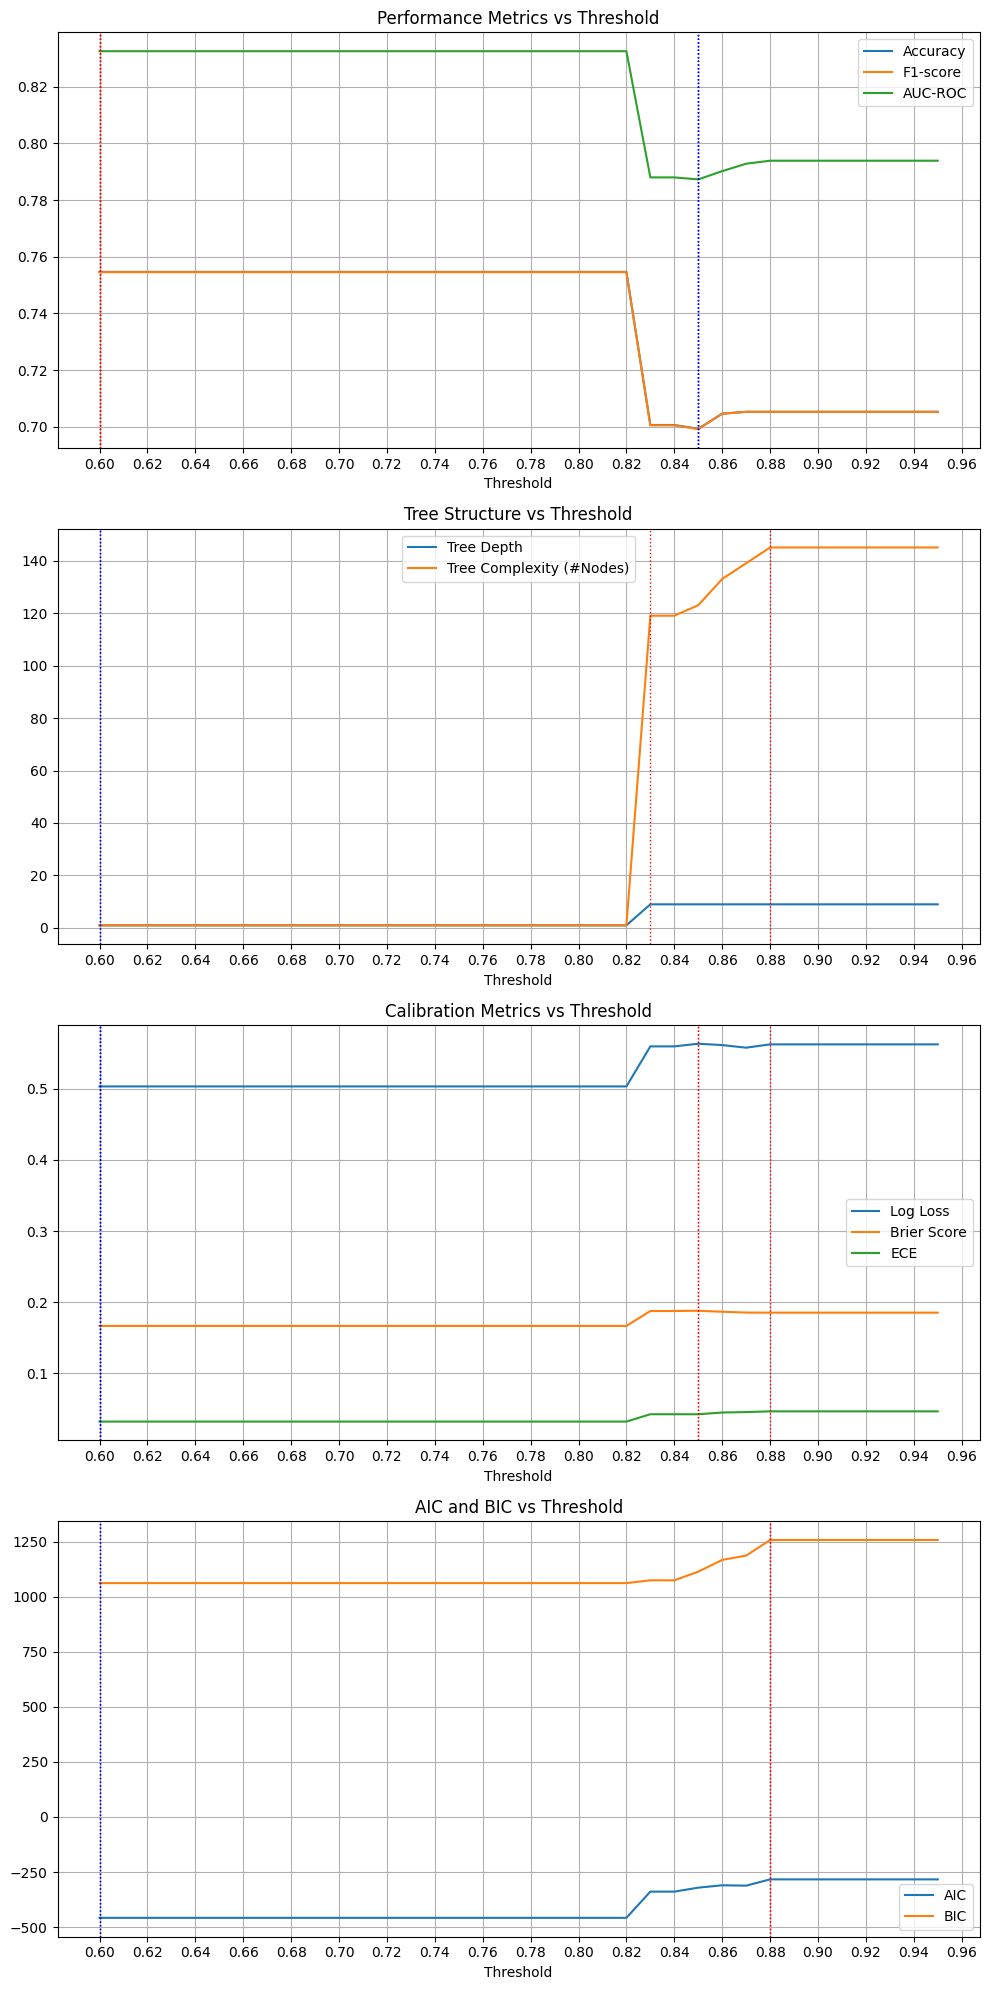

In [220]:
# Plotting
fig, axs = plt.subplots(4, 1, figsize=(10, 20))

for ax in axs:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=25))

df_results = results

# 1. Performance Metrics
axs[0].plot(df_results["threshold"], df_results["accuracy"], label="Accuracy")
axs[0].plot(df_results["threshold"], df_results["f1_score"], label="F1-score")
axs[0].plot(df_results["threshold"], df_results["auc"], label="AUC-ROC")
axs[0].set_title("Performance Metrics vs Threshold")
axs[0].set_xlabel("Threshold")
axs[0].legend()
axs[0].grid()
for metric in ["accuracy", "f1_score", "auc"]:
    annotate_min_max(axs[0], df_results["threshold"], df_results[metric], metric)

# 2. Tree Structure Metrics
axs[1].plot(df_results["threshold"], df_results["depth"], label="Tree Depth")
axs[1].plot(df_results["threshold"], df_results["complexity"], label="Tree Complexity (#Nodes)")
axs[1].set_title("Tree Structure vs Threshold")
axs[1].set_xlabel("Threshold")
axs[1].legend()
axs[1].grid()
for metric in ["depth", "complexity"]:
    annotate_min_max(axs[1], df_results["threshold"], df_results[metric], metric)

# 3. Calibration Metrics
axs[2].plot(df_results["threshold"], df_results["log_loss"], label="Log Loss")
axs[2].plot(df_results["threshold"], df_results["brier_score"], label="Brier Score")
axs[2].plot(df_results["threshold"], df_results["ece"], label="ECE")
axs[2].set_title("Calibration Metrics vs Threshold")
axs[2].set_xlabel("Threshold")
axs[2].legend()
axs[2].grid()
for metric in ["log_loss", "brier_score", "ece"]:
    annotate_min_max(axs[2], df_results["threshold"], df_results[metric], metric)

# 4. AIC/BIC in separate plot
axs[3].plot(df_results["threshold"], df_results["aic"], label="AIC")
axs[3].plot(df_results["threshold"], df_results["bic"], label="BIC")
axs[3].set_title("AIC and BIC vs Threshold")
axs[3].set_xlabel("Threshold")
axs[3].legend()
axs[3].grid()
for metric in ["aic", "bic"]:
    annotate_min_max(axs[3], df_results["threshold"], df_results[metric], metric)

plt.tight_layout()
plt.show()

In [221]:
summary

,metric,mean_value,min_value,min_threshold,max_value,max_threshold
0,accuracy,0.731190,0.699333,0.85,0.754667,0.60
1,f1_score,0.731121,0.699236,0.85,0.754568,0.60
2,auc,0.813722,0.787269,0.85,0.832470,0.60
3,log_loss,0.530355,0.503288,0.60,0.563281,0.85
4,brier_score,0.175759,0.166797,0.60,0.188105,0.85
5,ece,0.038540,0.032405,0.60,0.046751,0.88
6,depth,4.714286,1.000000,0.60,9.000000,0.83
7,complexity,64.571429,1.000000,0.60,145.000000,0.88
8,aic,-384.133193,-457.890118,0.60,-283.327379,0.88
9,bic,1128.616555,1061.690913,0.60,1257.506534,0.88


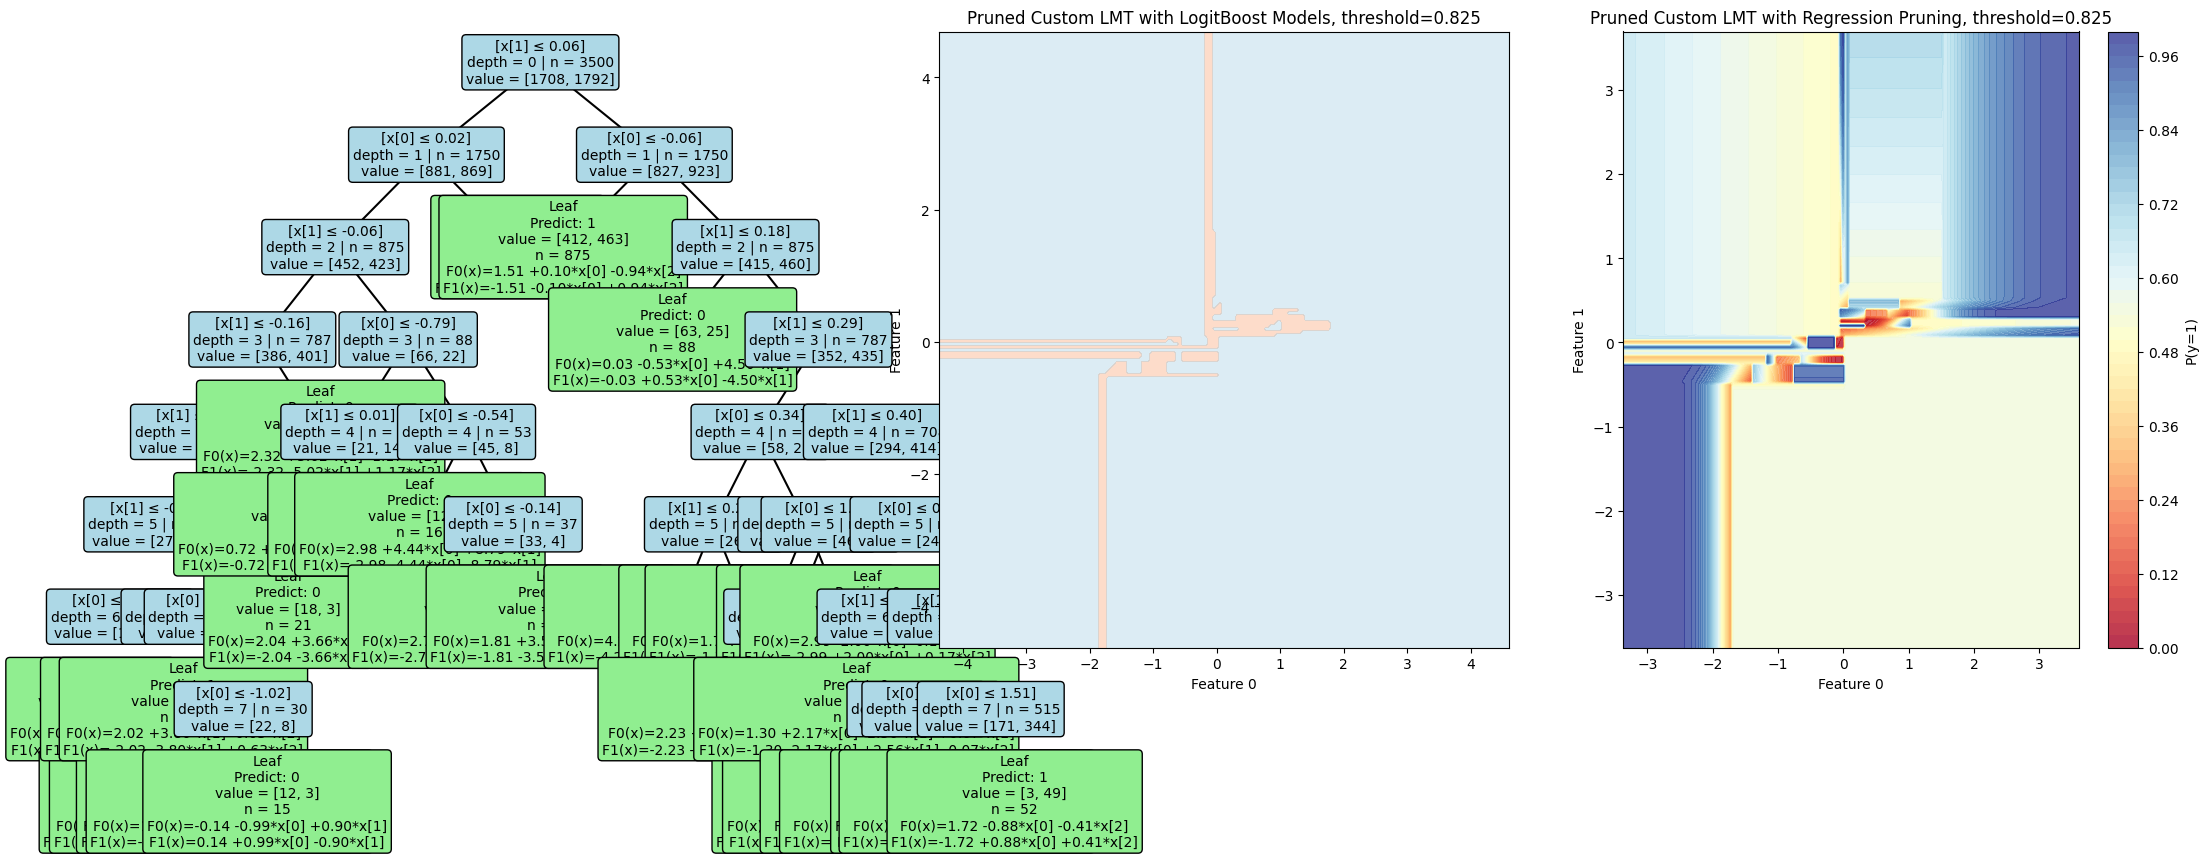

In [224]:
threshold_test = 0.825  # Example threshold for testing

pruned_tree_test, pruned_node_models_test = spline.regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=threshold_test, multiclass=False, average='macro', verbose=False)

# Proability regions
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

spline.plot_custom_tree_with_models(pruned_tree_test, pruned_node_models_test, X_train, ax=ax[0],title=f"Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}")
ax[0].set_axis_off() 

spline.plot_decision_regions_custom_tree(X_train, y_train, pruned_tree_test, pruned_node_models_test,
    feature_pair=(0, 1), show_scatter=False, title=f'Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}', ax=ax[1])

spline.plot_probability_surface_custom_tree(
    pruned_tree_test, pruned_node_models_test, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title=f'Pruned Custom LMT with Regression Pruning, threshold={threshold_test}', ax=ax[2]
    )

plt.show()

## Second tree

``
Training iteration 7/30 with parameters: {'max_depth': 12, 'min_samples_leaf': 15, 'purity_threshold': 0.75}
Training time: 14.07 seconds
Accuracy: 0.6620
``

In [184]:
results, summary, tree, node_models = results_from_tree(max_depth=12, min_samples_leaf=20, purity_threshold=0.8)

Feature 0, tau = -1.26, AUC_L = 0.697, AUC_R = 0.596, Weighted AUC = 0.606
Feature 0, tau = -0.83, AUC_L = 0.723, AUC_R = 0.674, Weighted AUC = 0.684
Feature 0, tau = -0.51, AUC_L = 0.739, AUC_R = 0.730, Weighted AUC = 0.733
Feature 0, tau = -0.24, AUC_L = 0.761, AUC_R = 0.754, Weighted AUC = 0.757
Feature 0, tau = 0.01, AUC_L = 0.772, AUC_R = 0.753, Weighted AUC = 0.762
Feature 0, tau = 0.26, AUC_L = 0.759, AUC_R = 0.731, Weighted AUC = 0.747
Feature 0, tau = 0.53, AUC_L = 0.714, AUC_R = 0.724, Weighted AUC = 0.717
Feature 0, tau = 0.84, AUC_L = 0.656, AUC_R = 0.717, Weighted AUC = 0.668
Feature 0, tau = 1.27, AUC_L = 0.584, AUC_R = 0.682, Weighted AUC = 0.594
Feature 1, tau = -1.30, AUC_L = 0.695, AUC_R = 0.599, Weighted AUC = 0.608
Feature 1, tau = -0.85, AUC_L = 0.732, AUC_R = 0.668, Weighted AUC = 0.681
Feature 1, tau = -0.54, AUC_L = 0.723, AUC_R = 0.727, Weighted AUC = 0.726
Feature 1, tau = -0.25, AUC_L = 0.740, AUC_R = 0.763, Weighted AUC = 0.754
Feature 1, tau = 0.01, AUC_L =

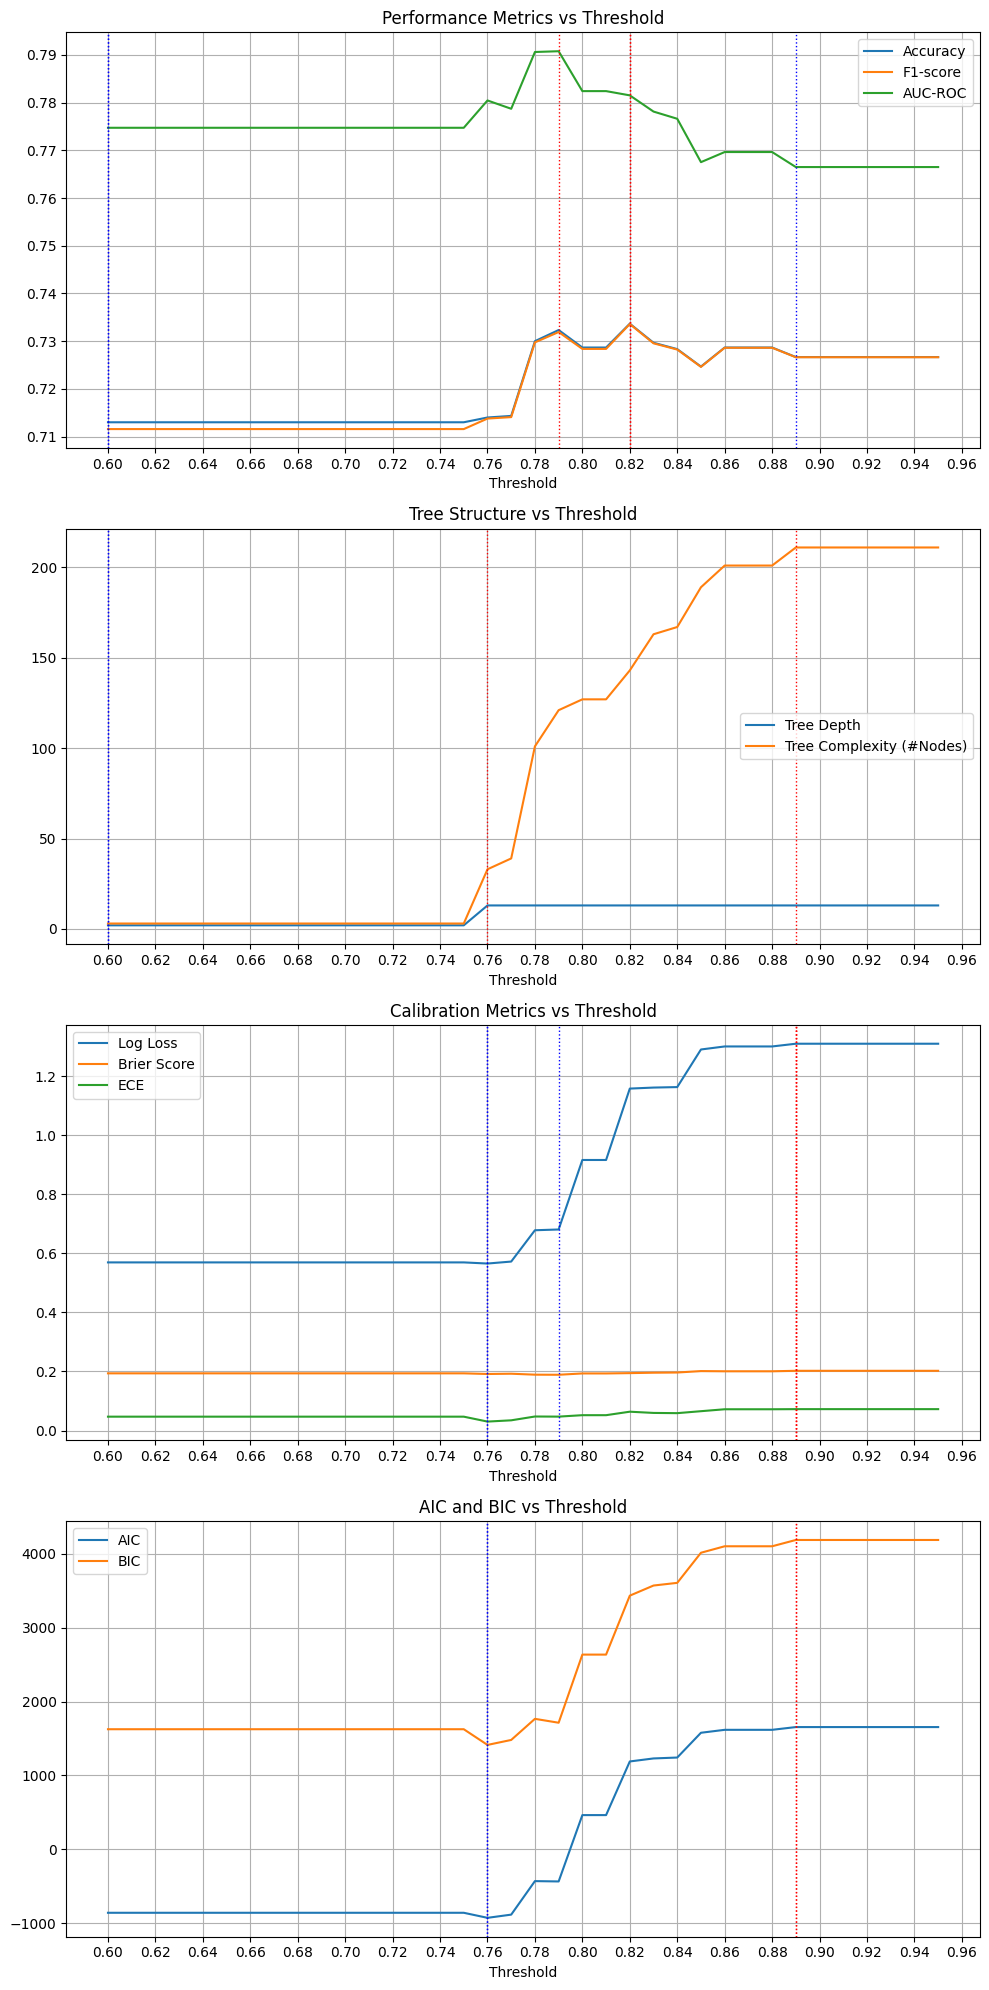

In [185]:
# Plotting
fig, axs = plt.subplots(4, 1, figsize=(10, 20))

for ax in axs:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=25))

df_results = results

# 1. Performance Metrics
axs[0].plot(df_results["threshold"], df_results["accuracy"], label="Accuracy")
axs[0].plot(df_results["threshold"], df_results["f1_score"], label="F1-score")
axs[0].plot(df_results["threshold"], df_results["auc"], label="AUC-ROC")
axs[0].set_title("Performance Metrics vs Threshold")
axs[0].set_xlabel("Threshold")
axs[0].legend()
axs[0].grid()
for metric in ["accuracy", "f1_score", "auc"]:
    annotate_min_max(axs[0], df_results["threshold"], df_results[metric], metric)

# 2. Tree Structure Metrics
axs[1].plot(df_results["threshold"], df_results["depth"], label="Tree Depth")
axs[1].plot(df_results["threshold"], df_results["complexity"], label="Tree Complexity (#Nodes)")
axs[1].set_title("Tree Structure vs Threshold")
axs[1].set_xlabel("Threshold")
axs[1].legend()
axs[1].grid()
for metric in ["depth", "complexity"]:
    annotate_min_max(axs[1], df_results["threshold"], df_results[metric], metric)

# 3. Calibration Metrics
axs[2].plot(df_results["threshold"], df_results["log_loss"], label="Log Loss")
axs[2].plot(df_results["threshold"], df_results["brier_score"], label="Brier Score")
axs[2].plot(df_results["threshold"], df_results["ece"], label="ECE")
axs[2].set_title("Calibration Metrics vs Threshold")
axs[2].set_xlabel("Threshold")
axs[2].legend()
axs[2].grid()
for metric in ["log_loss", "brier_score", "ece"]:
    annotate_min_max(axs[2], df_results["threshold"], df_results[metric], metric)

# 4. AIC/BIC in separate plot
axs[3].plot(df_results["threshold"], df_results["aic"], label="AIC")
axs[3].plot(df_results["threshold"], df_results["bic"], label="BIC")
axs[3].set_title("AIC and BIC vs Threshold")
axs[3].set_xlabel("Threshold")
axs[3].legend()
axs[3].grid()
for metric in ["aic", "bic"]:
    annotate_min_max(axs[3], df_results["threshold"], df_results[metric], metric)

plt.tight_layout()
plt.show()

In [186]:
summary

,metric,mean_value,min_value,min_threshold,max_value,max_threshold
0,accuracy,0.722893,0.713000,0.60,0.733667,0.82
1,f1_score,0.722397,0.711573,0.60,0.733590,0.82
2,auc,0.774330,0.766491,0.89,0.790767,0.79
3,log_loss,0.954980,0.565705,0.76,1.310485,0.89
4,brier_score,0.196566,0.188853,0.79,0.202274,0.89
5,ece,0.057425,0.030233,0.76,0.072369,0.89
6,depth,9.857143,2.000000,0.60,13.000000,0.76
7,complexity,118.357143,3.000000,0.60,211.000000,0.89
8,aic,465.644941,-929.046464,0.76,1655.191285,0.89
9,bic,2890.501333,1413.436887,0.76,4189.878398,0.89


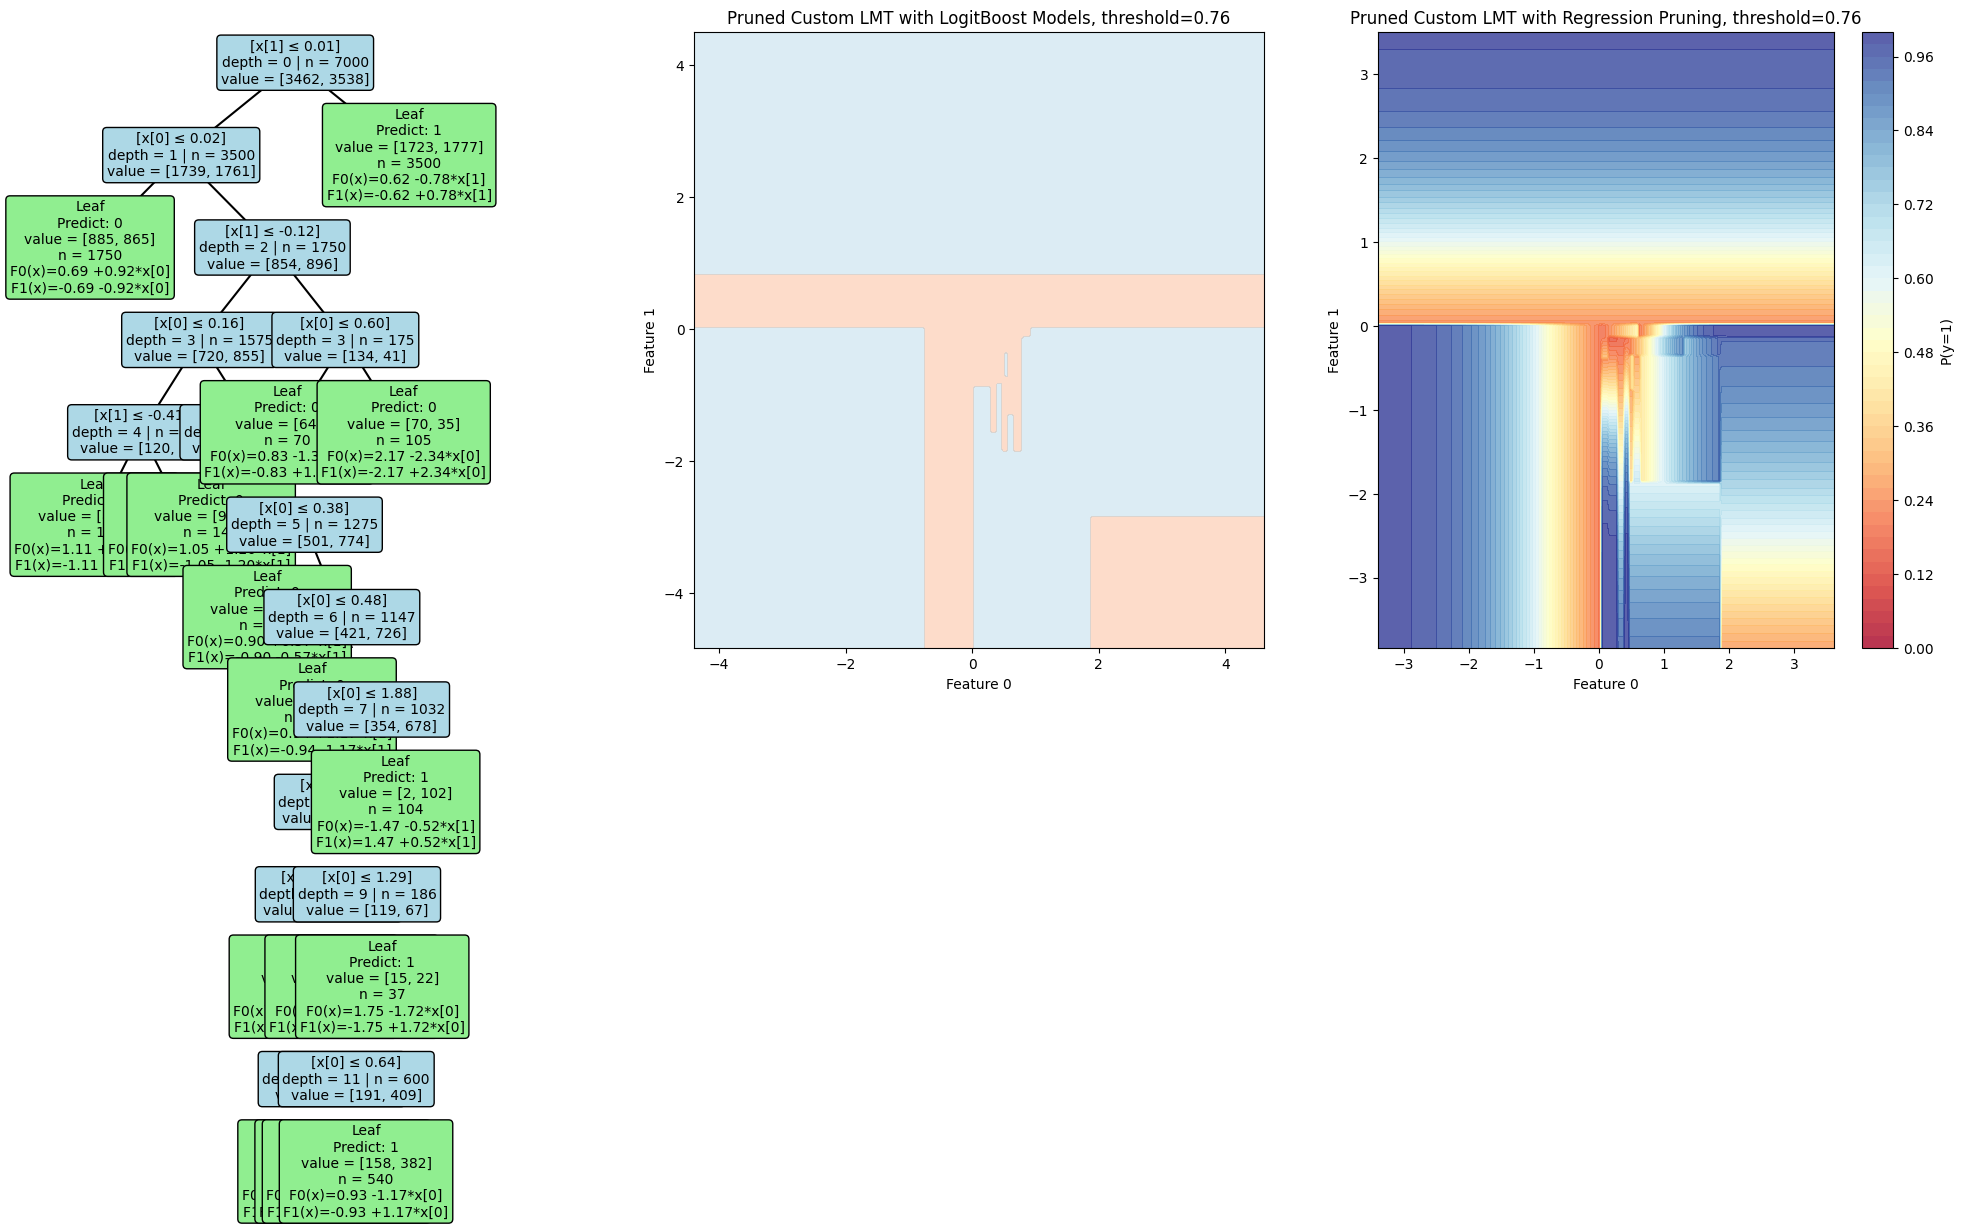

In [190]:
threshold_test = 0.76  # Example threshold for testing

pruned_tree_test, pruned_node_models_test = spline.regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=threshold_test, multiclass=False, average='macro', verbose=False)

# Proability regions
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

spline.plot_custom_tree_with_models(pruned_tree_test, pruned_node_models_test, X_train, ax=ax[0],title=f"Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}")
ax[0].set_axis_off() 

spline.plot_decision_regions_custom_tree(X_train, y_train, pruned_tree_test, pruned_node_models_test,
    feature_pair=(0, 1), show_scatter=False, title=f'Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}', ax=ax[1])

spline.plot_probability_surface_custom_tree(
    pruned_tree_test, pruned_node_models_test, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title=f'Pruned Custom LMT with Regression Pruning, threshold={threshold_test}', ax=ax[2]
    )

plt.show()

## Third tree
Training iteration 8/30 with parameters: {'max_depth': 8, 'min_samples_leaf': 30, 'purity_threshold': 0.75}
Training time: 19.46 seconds
Accuracy: 0.6860

In [191]:
results, summary, tree, node_models = results_from_tree(max_depth=8, min_samples_leaf=30, purity_threshold=0.75)

Feature 0, tau = -1.26, AUC_L = 0.697, AUC_R = 0.596, Weighted AUC = 0.606
Feature 0, tau = -0.83, AUC_L = 0.723, AUC_R = 0.674, Weighted AUC = 0.684
Feature 0, tau = -0.51, AUC_L = 0.739, AUC_R = 0.730, Weighted AUC = 0.733
Feature 0, tau = -0.24, AUC_L = 0.761, AUC_R = 0.754, Weighted AUC = 0.757
Feature 0, tau = 0.01, AUC_L = 0.772, AUC_R = 0.753, Weighted AUC = 0.762
Feature 0, tau = 0.26, AUC_L = 0.759, AUC_R = 0.731, Weighted AUC = 0.747
Feature 0, tau = 0.53, AUC_L = 0.714, AUC_R = 0.724, Weighted AUC = 0.717
Feature 0, tau = 0.84, AUC_L = 0.656, AUC_R = 0.717, Weighted AUC = 0.668
Feature 0, tau = 1.27, AUC_L = 0.584, AUC_R = 0.682, Weighted AUC = 0.594
Feature 1, tau = -1.30, AUC_L = 0.695, AUC_R = 0.599, Weighted AUC = 0.608
Feature 1, tau = -0.85, AUC_L = 0.732, AUC_R = 0.668, Weighted AUC = 0.681
Feature 1, tau = -0.54, AUC_L = 0.723, AUC_R = 0.727, Weighted AUC = 0.726
Feature 1, tau = -0.25, AUC_L = 0.740, AUC_R = 0.763, Weighted AUC = 0.754
Feature 1, tau = 0.01, AUC_L =

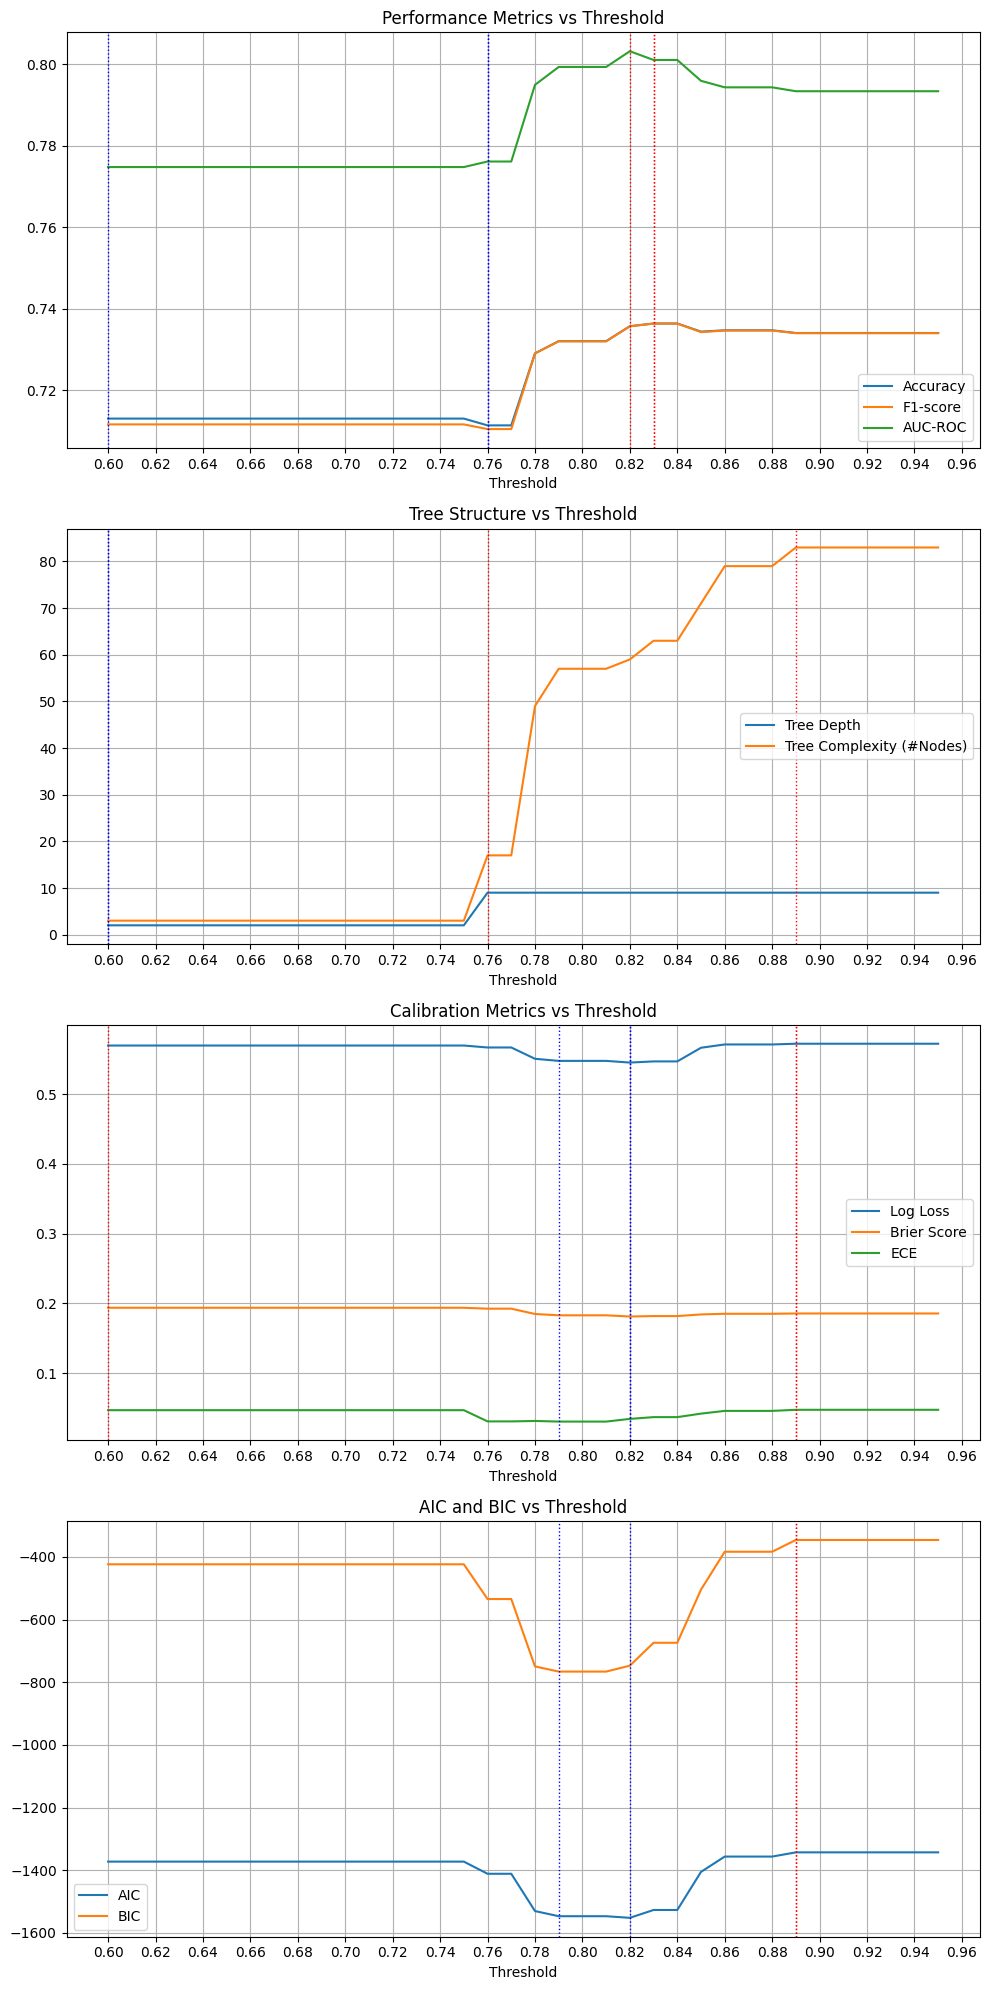

In [192]:
# Plotting
fig, axs = plt.subplots(4, 1, figsize=(10, 20))

for ax in axs:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=25))

df_results = results

# 1. Performance Metrics
axs[0].plot(df_results["threshold"], df_results["accuracy"], label="Accuracy")
axs[0].plot(df_results["threshold"], df_results["f1_score"], label="F1-score")
axs[0].plot(df_results["threshold"], df_results["auc"], label="AUC-ROC")
axs[0].set_title("Performance Metrics vs Threshold")
axs[0].set_xlabel("Threshold")
axs[0].legend()
axs[0].grid()
for metric in ["accuracy", "f1_score", "auc"]:
    annotate_min_max(axs[0], df_results["threshold"], df_results[metric], metric)

# 2. Tree Structure Metrics
axs[1].plot(df_results["threshold"], df_results["depth"], label="Tree Depth")
axs[1].plot(df_results["threshold"], df_results["complexity"], label="Tree Complexity (#Nodes)")
axs[1].set_title("Tree Structure vs Threshold")
axs[1].set_xlabel("Threshold")
axs[1].legend()
axs[1].grid()
for metric in ["depth", "complexity"]:
    annotate_min_max(axs[1], df_results["threshold"], df_results[metric], metric)

# 3. Calibration Metrics
axs[2].plot(df_results["threshold"], df_results["log_loss"], label="Log Loss")
axs[2].plot(df_results["threshold"], df_results["brier_score"], label="Brier Score")
axs[2].plot(df_results["threshold"], df_results["ece"], label="ECE")
axs[2].set_title("Calibration Metrics vs Threshold")
axs[2].set_xlabel("Threshold")
axs[2].legend()
axs[2].grid()
for metric in ["log_loss", "brier_score", "ece"]:
    annotate_min_max(axs[2], df_results["threshold"], df_results[metric], metric)

# 4. AIC/BIC in separate plot
axs[3].plot(df_results["threshold"], df_results["aic"], label="AIC")
axs[3].plot(df_results["threshold"], df_results["bic"], label="BIC")
axs[3].set_title("AIC and BIC vs Threshold")
axs[3].set_xlabel("Threshold")
axs[3].legend()
axs[3].grid()
for metric in ["aic", "bic"]:
    annotate_min_max(axs[3], df_results["threshold"], df_results[metric], metric)

plt.tight_layout()
plt.show()

In [193]:
summary

,metric,mean_value,min_value,min_threshold,max_value,max_threshold
0,accuracy,0.726298,0.711333,0.76,0.736333,0.83
1,f1_score,0.725798,0.710425,0.76,0.736305,0.83
2,auc,0.788568,0.774722,0.60,0.803147,0.82
3,log_loss,0.564527,0.545153,0.82,0.572151,0.89
4,brier_score,0.187497,0.181143,0.82,0.193675,0.60
5,ece,0.042116,0.030536,0.79,0.047413,0.89
6,depth,7.000000,2.000000,0.60,9.000000,0.76
7,complexity,48.285714,3.000000,0.60,83.000000,0.89
8,aic,-1409.209513,-1552.067536,0.82,-1343.058521,0.89
9,bic,-488.519170,-766.075653,0.79,-346.001505,0.89


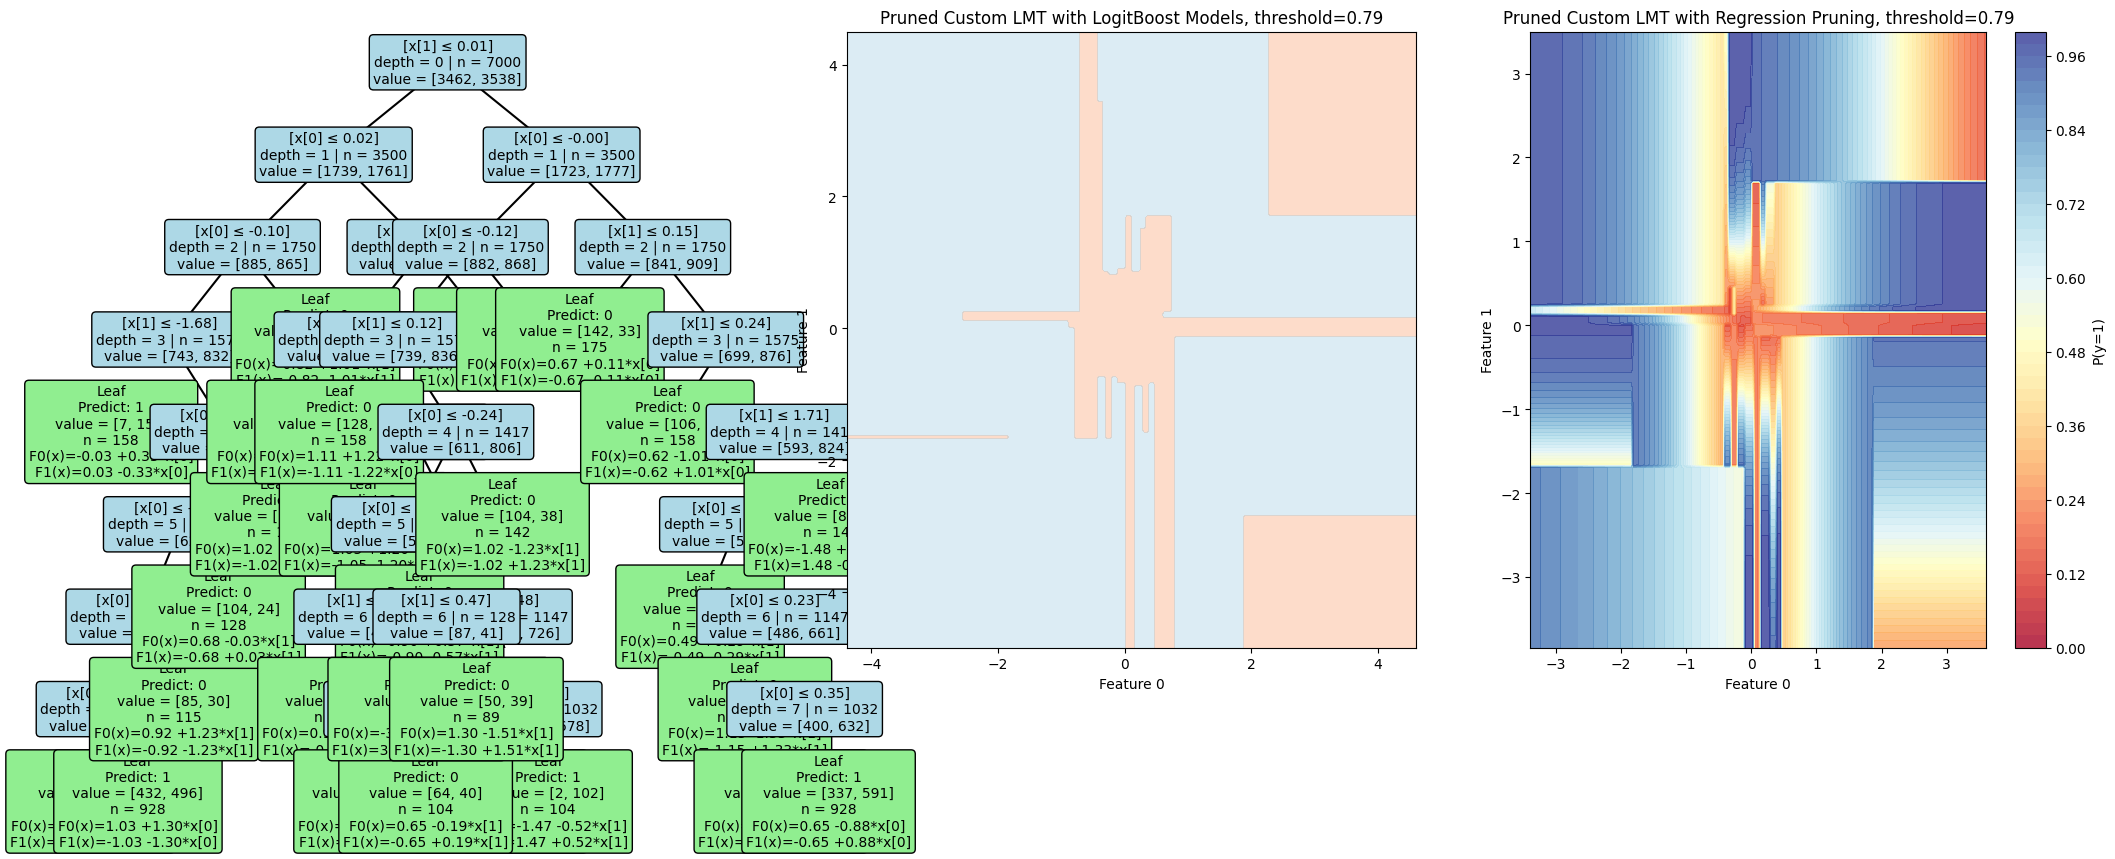

In [196]:
threshold_test = 0.79  # Example threshold for testing

pruned_tree_test, pruned_node_models_test = spline.regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=threshold_test, multiclass=False, average='macro', verbose=False)

# Proability regions
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

spline.plot_custom_tree_with_models(pruned_tree_test, pruned_node_models_test, X_train, ax=ax[0],title=f"Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}")
ax[0].set_axis_off() 

spline.plot_decision_regions_custom_tree(X_train, y_train, pruned_tree_test, pruned_node_models_test,
    feature_pair=(0, 1), show_scatter=False, title=f'Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}', ax=ax[1])

spline.plot_probability_surface_custom_tree(
    pruned_tree_test, pruned_node_models_test, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title=f'Pruned Custom LMT with Regression Pruning, threshold={threshold_test}', ax=ax[2]
    )

plt.show()

## Fourth tree
default  
``
max_depth = 10  
min_samples_leaf = 20  
purity_threshold = 0.85
``

In [197]:
results, summary, tree, node_models = results_from_tree()

Feature 0, tau = -1.26, AUC_L = 0.697, AUC_R = 0.596, Weighted AUC = 0.606
Feature 0, tau = -0.83, AUC_L = 0.723, AUC_R = 0.674, Weighted AUC = 0.684
Feature 0, tau = -0.51, AUC_L = 0.739, AUC_R = 0.730, Weighted AUC = 0.733
Feature 0, tau = -0.24, AUC_L = 0.761, AUC_R = 0.754, Weighted AUC = 0.757
Feature 0, tau = 0.01, AUC_L = 0.772, AUC_R = 0.753, Weighted AUC = 0.762
Feature 0, tau = 0.26, AUC_L = 0.759, AUC_R = 0.731, Weighted AUC = 0.747
Feature 0, tau = 0.53, AUC_L = 0.714, AUC_R = 0.724, Weighted AUC = 0.717
Feature 0, tau = 0.84, AUC_L = 0.656, AUC_R = 0.717, Weighted AUC = 0.668
Feature 0, tau = 1.27, AUC_L = 0.584, AUC_R = 0.682, Weighted AUC = 0.594
Feature 1, tau = -1.30, AUC_L = 0.695, AUC_R = 0.599, Weighted AUC = 0.608
Feature 1, tau = -0.85, AUC_L = 0.732, AUC_R = 0.668, Weighted AUC = 0.681
Feature 1, tau = -0.54, AUC_L = 0.723, AUC_R = 0.727, Weighted AUC = 0.726
Feature 1, tau = -0.25, AUC_L = 0.740, AUC_R = 0.763, Weighted AUC = 0.754
Feature 1, tau = 0.01, AUC_L =

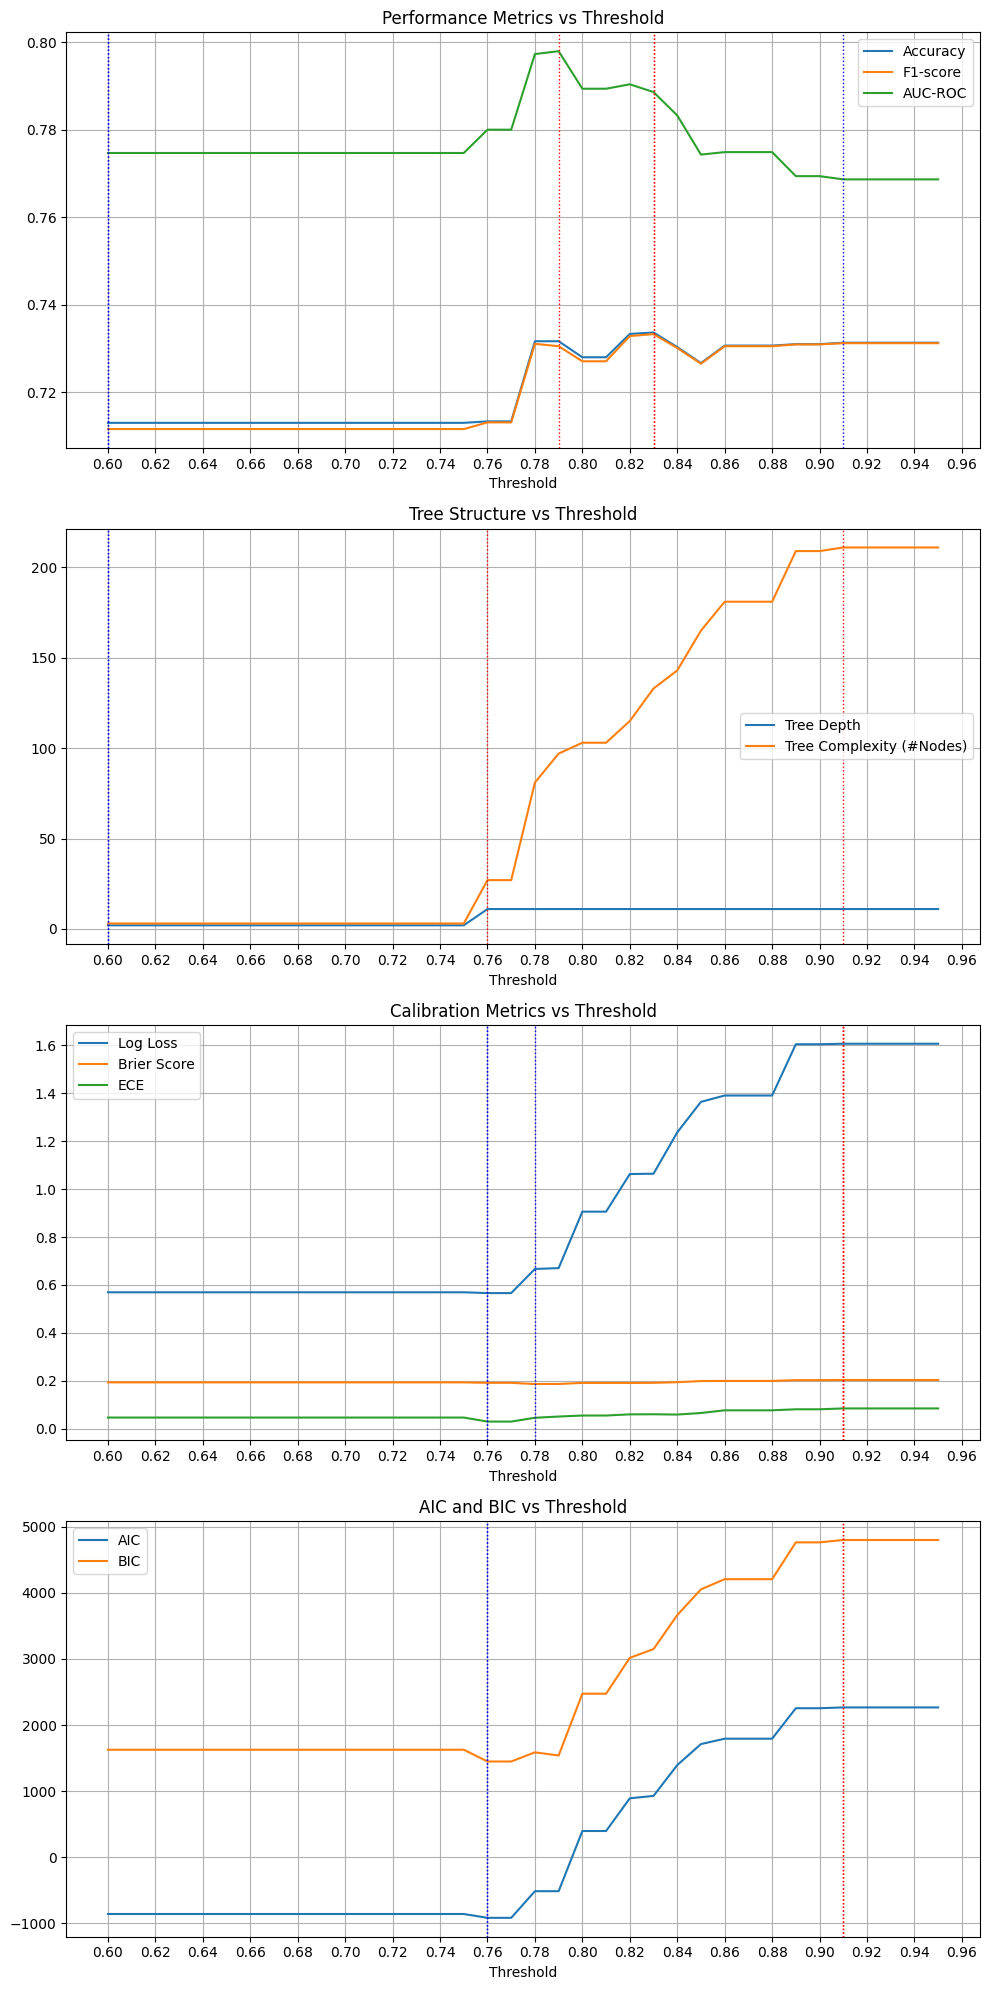

In [198]:
# Plotting
fig, axs = plt.subplots(4, 1, figsize=(10, 20))

for ax in axs:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=25))

df_results = results

# 1. Performance Metrics
axs[0].plot(df_results["threshold"], df_results["accuracy"], label="Accuracy")
axs[0].plot(df_results["threshold"], df_results["f1_score"], label="F1-score")
axs[0].plot(df_results["threshold"], df_results["auc"], label="AUC-ROC")
axs[0].set_title("Performance Metrics vs Threshold")
axs[0].set_xlabel("Threshold")
axs[0].legend()
axs[0].grid()
for metric in ["accuracy", "f1_score", "auc"]:
    annotate_min_max(axs[0], df_results["threshold"], df_results[metric], metric)

# 2. Tree Structure Metrics
axs[1].plot(df_results["threshold"], df_results["depth"], label="Tree Depth")
axs[1].plot(df_results["threshold"], df_results["complexity"], label="Tree Complexity (#Nodes)")
axs[1].set_title("Tree Structure vs Threshold")
axs[1].set_xlabel("Threshold")
axs[1].legend()
axs[1].grid()
for metric in ["depth", "complexity"]:
    annotate_min_max(axs[1], df_results["threshold"], df_results[metric], metric)

# 3. Calibration Metrics
axs[2].plot(df_results["threshold"], df_results["log_loss"], label="Log Loss")
axs[2].plot(df_results["threshold"], df_results["brier_score"], label="Brier Score")
axs[2].plot(df_results["threshold"], df_results["ece"], label="ECE")
axs[2].set_title("Calibration Metrics vs Threshold")
axs[2].set_xlabel("Threshold")
axs[2].legend()
axs[2].grid()
for metric in ["log_loss", "brier_score", "ece"]:
    annotate_min_max(axs[2], df_results["threshold"], df_results[metric], metric)

# 4. AIC/BIC in separate plot
axs[3].plot(df_results["threshold"], df_results["aic"], label="AIC")
axs[3].plot(df_results["threshold"], df_results["bic"], label="BIC")
axs[3].set_title("AIC and BIC vs Threshold")
axs[3].set_xlabel("Threshold")
axs[3].legend()
axs[3].grid()
for metric in ["aic", "bic"]:
    annotate_min_max(axs[3], df_results["threshold"], df_results[metric], metric)

plt.tight_layout()
plt.show()

In [199]:
summary

,metric,mean_value,min_value,min_threshold,max_value,max_threshold
0,accuracy,0.724452,0.713000,0.60,0.733667,0.83
1,f1_score,0.723817,0.711573,0.60,0.733288,0.83
2,auc,0.777711,0.768687,0.91,0.798001,0.79
3,log_loss,1.035000,0.566173,0.76,1.606653,0.91
4,brier_score,0.196038,0.186839,0.78,0.203585,0.91
5,ece,0.060978,0.030072,0.76,0.084909,0.91
6,depth,8.428571,2.000000,0.60,11.000000,0.76
7,complexity,108.357143,3.000000,0.60,211.000000,0.91
8,aic,613.624881,-918.567567,0.76,2266.459004,0.91
9,bic,3000.726963,1447.941255,0.76,4801.146118,0.91


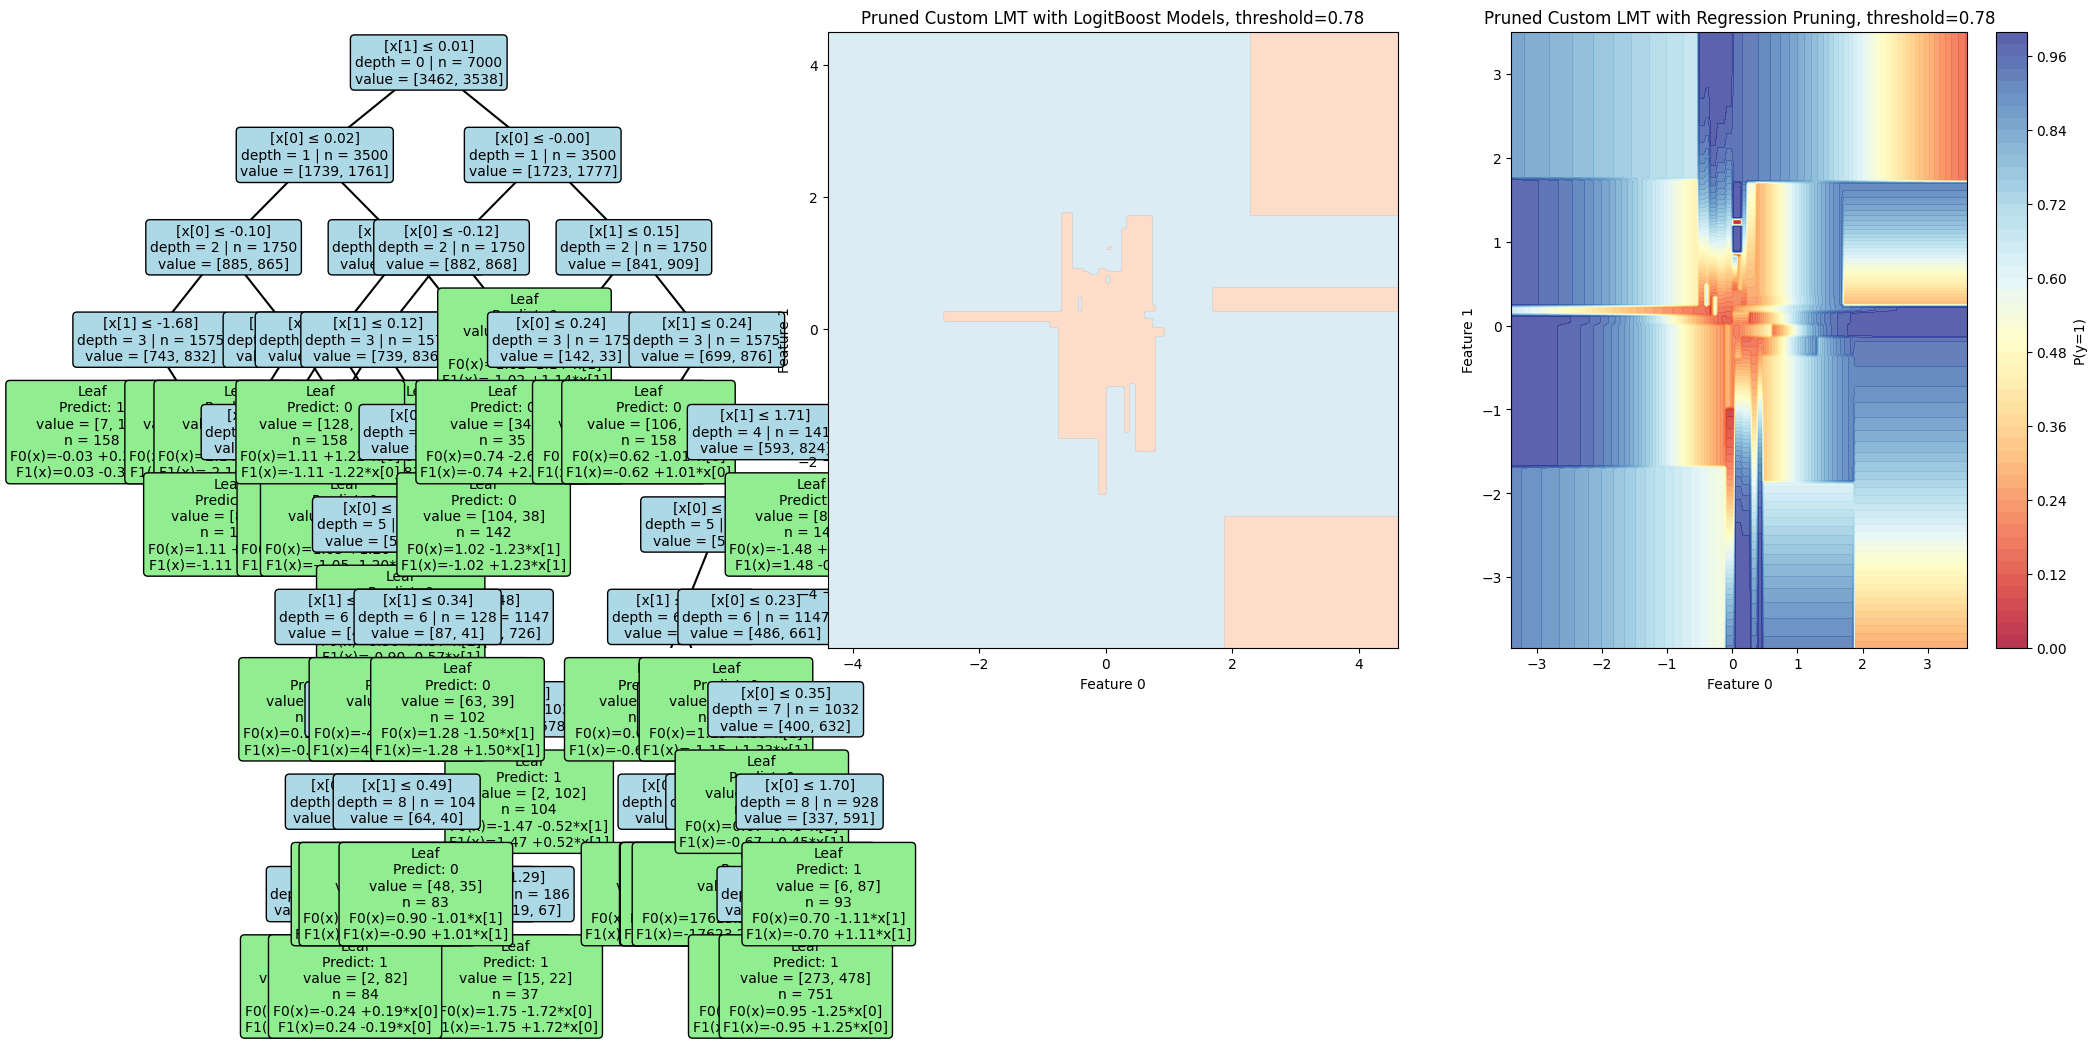

In [201]:
threshold_test = 0.78  # Example threshold for testing

pruned_tree_test, pruned_node_models_test = spline.regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=threshold_test, multiclass=False, average='macro', verbose=False)

# Proability regions
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

spline.plot_custom_tree_with_models(pruned_tree_test, pruned_node_models_test, X_train, ax=ax[0],title=f"Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}")
ax[0].set_axis_off() 

spline.plot_decision_regions_custom_tree(X_train, y_train, pruned_tree_test, pruned_node_models_test,
    feature_pair=(0, 1), show_scatter=False, title=f'Pruned Custom LMT with LogitBoost Models, threshold={threshold_test}', ax=ax[1])

spline.plot_probability_surface_custom_tree(
    pruned_tree_test, pruned_node_models_test, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title=f'Pruned Custom LMT with Regression Pruning, threshold={threshold_test}', ax=ax[2]
    )

plt.show()